# Neural Approximation of Dynamic Programming Solutions: Evidence from the Rust Bus Replacement Model

## Table of Contents 

1. Introduction

2. The Classical Rust Benchmark

3. The Computational Crisis of Classical Dynamic Programming

4. Assessment of Alternative Neural Learning Targets in the Rust Model

5. Deep Learning Recovery of the Selected Learning Target from Model Structure  

6. Discussion and Conclusion

References

AI Use Disclosure

## Project Overview

### Contributions

1. To reproduce the Rust bus replacement model and construct benchmark dynamic programming solution objects for neural approximation.

2. To analyze the computational bottlenecks of solving and estimating the Rust model, review the major methodological responses to these bottlenecks, and establish the motivation for neural approximation.

3. To conduct a screening experiment that identifies the most suitable learning target among three hierarchically related solution objects in the Rust dynamic programming framework.

4. To develop a structure-guided learning framework that examines whether the selected learning target can be recovered directly from the Rust model without relying on benchmark solution objects.

### Discussion 

To discuss the unified structure-guided learning framework developed in this study by integrating target selection, neural approximation, and structural recovery, and to examine the transition from data-driven learning to structure-guided learning.

### Conclusion

To reflect on the trade-off between classical dynamic programming and neural approximation from the perspective of computational economics, and to argue that methodological replacement follows the same dynamic replacement logic embodied in the Rust model.

# 1 Introduction

## 1.1 Dynamic Decision-Making and Structural Modeling

Many economic decisions are dynamic rather than static. Current actions influence future opportunities, constraints, and outcomes, making decision problems inherently intertemporal. As a result, decision makers must evaluate not only immediate consequences but also the future implications of their choices.

Analyzing such behavior requires a framework that links actions to future states. **Dynamic decision-making** treats behavior as the outcome of forward-looking optimization, where decisions are made with consideration of both current and future consequences.

This perspective motivates **structural modeling**. Rather than modeling observed behavior through statistical correlations alone, structural models seek to characterize the underlying decision mechanism that generates observed choices. The objective is to explain observed behavior in terms of preferences, constraints, expectations, and optimization.

## 1.2 Dynamic Programming and Structural Estimation 

**Dynamic programming** provides the formal framework for analyzing forward-looking behavior. A dynamic decision problem can be represented by states, actions, transition dynamics, and value functions. The central idea is that the value of a decision depends not only on its immediate payoff but also on its effect on future opportunities.

Its recursive structure of dynamic programming is commonly represented through the **Bellman equation**, which characterizes optimal behavior over time. Solving the Bellman equation yields the value function and the associated optimal policy.

In empirical applications, researchers typically observe actions rather than preferences or value functions. **Structural estimation** addresses this challenge by using observed behavior to recover the parameters governing the underlying decision process. Dynamic programming defines the behavioral model, whereas structural estimation links the model to observed data. 

## 1.3 Computational Challenges and the Motivation for Approximation

While dynamic programming provides a powerful framework for sequential decision-making, solving dynamic models often requires repeated Bellman iterations and fixed-point computations. As the state space expands, computational costs increase rapidly because of the **curse of dimensionality**, making exact solutions increasingly difficult to obtain.

The computational burden becomes even greater in **structural estimation**, where the dynamic optimization problem must be solved repeatedly for different parameter values. As a result, estimation can become substantially more expensive than solving the model itself. 

These computational challenges have motivated  **approximation methods**. Instead of solving dynamic models exactly, approximation-based approaches seek to represent key components of the decision problem more efficiently while preserving their essential economic structure.

## 1.4 Project Objectives and Structure 

This project examines whether **neural-network-based approximation methods** can recover the **selected solution object** in **dynamic programming**, while preserving the **economic structure** of the original model.

Chapter 2 develops the classical Rust benchmark based on dynamic programming and structural estimation. Chapter 3 discusses the computational limitations of exact solution methods and reviews the historical development of approximation-based approaches. Chapter 4 evaluates alternative neural learning targets within the Rust model and identifies the most suitable target for approximation. Chapter 5 proposes a structure-guided neural learning framework based on the Bellman equation and examines whether it can recover the selected learning target, decision behavior, and economic structure. Finally, Chapter 6 discusses the main findings, limitations, and broader implications of neural approximation methods for dynamic structural models.

# 2 The Classical Rust Benchmark 

## 2.1 The Rust Bus Engine Replacement Problem

Rust (1987) examines the engine replacement decisions of Harold Zurcher, the maintenance superintendent of Madison Metropolitan Bus Company. The central decision problem is when an aging bus engine should be replaced.

The decision problem can be summarized as follows:
- **State:** accumulated mileage since the last engine replacement.
- **Actions:** **Keep** the current engine or **Replace** it with a rebuilt engine.
- **Trade-off:** replacement involves a large immediate cost, while keeping an aging engine leads to increasing maintenance expenses and a higher probability of breakdown.

A key feature of the problem is that **current decisions affect future states**. If the engine is kept, mileage continues to accumulate and the engine deteriorates further. If the engine is replaced, the mileage state is reset and the replacement cycle starts again. The decision maker therefore faces a sequence of interrelated decisions rather than a series of isolated one-period choices. 

Because future operating costs depend on current decisions, the problem is inherently dynamic. A static model would compare only contemporaneous maintenance and replacement costs and would therefore fail to explain preventive replacement, where engines are replaced before complete failure in anticipation of future deterioration. To capture this intertemporal trade-off, Rust formulates the problem as a **dynamic optimization problem** and models the replacement decision as a **regenerative optimal stopping problem**.

The resulting framework later became the canonical example of a **dynamic discrete choice (DDC) model**, providing the foundation for the structural analysis of forward-looking decision making under uncertainty.

## 2.2 The Rust Bus Engine Replacement Dataset 

### 2.2.1 Data Source

The dataset used in this project is the Rust (1987) bus engine replacement dataset distributed through the `rust-data` repository maintained by the OpenSourceEconomics community: https://github.com/OpenSourceEconomics/rust-data

The repository contains the original bus engine replacement data together with the associated preprocessing functions.

### 2.2.2 Data Preparation

The raw data are stored in the original format used for the Rust bus engine replacement model. The preprocessing functions provided in the repository transform the original records into a structured dataset suitable for analysis.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Add the local rust-data repository to the Python path
sys.path.append("../data/rust-data")

from data.data_processing import data_reading, data_processing

The original Rust dataset is organized into several bus groups, each corresponding to a different set of buses in the Madison Metro fleet. In this project, I restrict the analysis to **bus group 4** in order to keep the empirical environment fixed across all solution methods.

In the Rust model, the condition of an engine is summarized by its accumulated mileage since the last replacement. As mileage increases, the engine becomes more likely to require maintenance and experience breakdowns, making mileage a key determinant of replacement decisions. To obtain a finite state space for dynamic programming, mileage is discretized into **5,000-mile intervals**. Each state index represents a mileage bin: state 0 corresponds to 0–4,999 miles, state 1 corresponds to 5,000–9,999 miles, and so on.

In [2]:
# Convert the original raw files into intermediate group-level pickle files.
data_reading()  

# Specify the data-processing configuration.
# Following Rust (1987), accumulated mileage is discretized into 5,000-mile intervals. 
init_dict = { "groups": "group_4", "binsize": 5000 }

# Process the selected bus group and construct the cleaned panel dataset.
df_clean = data_processing(init_dict)
df_clean.head()

state  mileage usage  decision
Bus_ID period                               
5297   0          0   2353.0   NaN         0
       1          1   6299.0   1.0         0
       2          2  10479.0   1.0         0
       3          3  15201.0   1.0         0
       4          4  20326.0   1.0         0

The dataset contains four main variables: 
- `state`: the discretized mileage state of the bus 
- `mileage`: the observed odometer reading 
- `usage`: the mileage increment used to model state transitions
- `decision`: the observed engine replacement decision

For the `decision` variable:
- `0` = keep the current engine 
- `1` = replace the engine 

In [3]:
# Convert key variables to numeric format for analysis.
df_clean["state"] = pd.to_numeric(df_clean["state"])
df_clean["mileage"] = pd.to_numeric(df_clean["mileage"])
df_clean["usage"] = pd.to_numeric(df_clean["usage"])

# Generate descriptive statistics for all numeric variables
df_clean.describe()

,state,mileage,usage,decision
count,4329.000000,4329.000000,4292.000000,4329.000000
mean,25.395934,129454.487179,0.620923,0.007623
std,18.940754,94712.232318,0.510948,0.086986
min,0.000000,5.000000,0.000000,0.000000
25%,9.000000,47911.000000,0.000000,0.000000
50%,21.000000,109232.000000,1.000000,0.000000
75%,40.000000,203623.000000,1.000000,0.000000
max,77.000000,387282.000000,2.000000,1.000000


In [4]:
# Count the number of observations for each decision outcome.
df_clean["decision"].value_counts()

decision
0    4296
1      33
Name: count, dtype: int64

After preprocessing, the sample contains 4,329 monthly observations, 78 discretized mileage states, and 33 engine replacement events. 

## 2.3 Constructing the Dynamic Programming Model 

This section translates the processed dataset into the components required for dynamic programming. In the Rust framework, a dynamic decision model is characterized by a state space, an action space, transition dynamics, and a cost structure.

Since this project focuses on neural approximation of dynamic programming solution objects rather than reproduce Rust’s original Nested Fixed Point (NFXP) estimation procedure, **the structural parameter estimates reported by Rust (1987) are treated as fixed** throughout the benchmark construction. These benchmark parameters are used to specify the transition dynamics and cost structure of the model.

### 2.3.1 Constructing Transition Dynamics

The transition dynamics describe how the mileage state evolves over time under different maintenance decisions. Following Rust (1987), the transition process is constructed using the estimated mileage increment parameters reported for Bus Group 4.

**Mileage Increment Process**

Following Rust (1987), mileage accumulation follows a discrete stochastic process. 

Let $$\Delta x_t = x_{t+1} - x_t$$ denote the mileage increment between two consecutive periods. Under the discretized state representation, the mileage increment can take three possible values $\Delta x_t \in \{0,1,2\}$. These increments represent increases of zero, one, or two mileage states within a single period.

**Transition Probabilities under Keep**

Following Rust (1987), the mileage increment process is characterized by the probabilities $$Pr(\Delta x_t = 0)=p_0$$ $$Pr(\Delta x_t = 1)=p_1$$ $$Pr(\Delta x_t = 2)=p_2$$

For Bus Group 4, the estimated transition parameters reported in Table V are $$p_0 = 0.392$$ $$p_1 = 0.595$$ $$p_2 = 0.013$$

These probabilities determine the likelihood of observing different mileage increments when the engine remains in service.

**State Transitions under Keep**

When the current engine is retained, the next-period mileage state evolves according to $$x_{t+1}=x_t+\Delta x_t$$

Consequently, the bus gradually moves toward higher mileage states over time. The probabilities $p_0$, $p_1$, and $p_2$ govern the rate at which mileage accumulates and the engine deteriorates over time.

**State Transitions under Replacement**

When the engine is replaced, the mileage state is reset to the condition of a new engine. The next-period state is therefore given by $$x_{t+1}=0+\Delta x_t$$

Consequently, $x_{t+1}\in\{0,1,2\}$. Replacement returns the system to the lowest mileage region while allowing for normal mileage accumulation during the following period.

**Transition Matrix Construction**

The transition dynamics are represented by the conditional transition probabilities $P(x' \mid x,a)$

Using the mileage increment probabilities above, two transition matrices are constructed:
- a **keep transition matrix**, describing state evolution when the current engine is retained;
- a **replacement transition matrix**, describing state evolution after engine replacement.

Each row of the transition matrix corresponds to $$Pr(x_{t+1}=x' \mid x_t=x,\ a_t=a)$$ and therefore represents a complete probability distribution over next-period states.

![](../figures/rust1987_tableV_transition_parameters.png)

In [5]:
# Construct Rust (1987) transition matrices using Group 4 transition probabilities.

# State space from the processed data.
# Each state is a 5,000-mile mileage-bin index.
states = np.sort(df_clean["state"].unique())
n_states = len(states)

# Rust (1987), Table V, Group 4 transition probabilities.
p0 = 0.392
p1 = 0.595
p2 = 0.013

# Transition matrix under the keep decision.
P_keep = np.zeros((n_states, n_states))

for i in range(n_states):
    P_keep[i, i] += p0

    if i + 1 < n_states:
        P_keep[i, i + 1] += p1
    else:
        P_keep[i, -1] += p1

    if i + 2 < n_states:
        P_keep[i, i + 2] += p2
    else:
        P_keep[i, -1] += p2

# Transition matrix under the replacement decision.
P_replace = np.zeros((n_states, n_states))

P_replace[:, 0] = p0
P_replace[:, 1] = p1
P_replace[:, 2] = p2

print("Number of states:", n_states)
print("Keep transition matrix shape:", P_keep.shape)
print("Replacement transition matrix shape:", P_replace.shape)
print("First five row sums of P_keep:", np.round(P_keep.sum(axis=1)[:5], 4))
print("First five row sums of P_replace:", np.round(P_replace.sum(axis=1)[:5], 4))

Number of states: 78
Keep transition matrix shape: (78, 78)
Replacement transition matrix shape: (78, 78)
First five row sums of P_keep: [1. 1. 1. 1. 1.]
First five row sums of P_replace: [1. 1. 1. 1. 1.]


The constructed transition matrices contain 78 mileage states, resulting in transition matrices of dimension $78\times78$. The first five row sums of both matrices are equal to one $[1,1,1,1,1]$.

Therefore, $$\sum_{x'}P(x'|x,a)=1$$ for every state-action pair, confirming that the constructed matrices satisfy the requirements of a valid Markov transition process.

The resulting matrices provide the numerical description of the state transition process and serve as the transition component of the Rust benchmark model. Together with the cost structure introduced in the next section, they form the basis for the Bellman representation and numerical solution of the model.

### 2.3.2 Specifying the Cost Structure

The transition dynamics describe how the mileage state evolves over time, but they do not determine which action is economically desirable. To compare alternative actions, the Rust model requires a cost structure that assigns an economic consequence to each action.

Following Rust (1987), two types of costs are considered:
- maintenance costs associated with continued engine operation;
- replacement costs incurred when a new engine is installed.

**Maintenance Costs**

The maintenance cost increases with the mileage state and is specified as $$MC(x)=0.001\,\theta_1 x$$

The parameter $\theta_1$ measures the sensitivity of maintenance costs to engine mileage.

**Replacement Costs**

Engine replacement requires a fixed replacement cost denoted by $RC$. Unlike maintenance costs, the replacement cost does not depend on the current mileage state.

**State-Dependent Costs**

Maintenance costs are state-dependent because engine deterioration accumulates over time. As mileage increases, engines experience greater wear and tear, more frequent maintenance requirements, and a higher likelihood of mechanical failure.

Consequently, $MC(x)$ is an increasing function of the mileage state.

**Action-Specific Cost Functions**

The economic consequences of the two available actions can therefore be summarized by the action-specific cost function $C(x,a)$

For the keep decision, $$C(x,\text{keep})=0.001\,\theta_1 x$$

For the replacement decision, $$C(x,\text{replace})=RC$$

These expressions define the per-period costs associated with each action and constitute the cost component of the dynamic programming model.

**Economic Interpretation of the Cost Structure**

The cost structure creates a trade-off between continued engine operation and engine replacement. Keeping the current engine avoids the immediate replacement cost but leads to higher expected maintenance costs as mileage accumulates. Replacing the engine requires paying a fixed replacement cost but resets the engine condition to a low-mileage state.

This trade-off is represented by the dynamic programming model through the action-specific cost function.

### 2.3.3 Markov Decision Process Representation

The engine replacement problem can now be formulated as a finite-state Markov Decision Process (MDP).

The model consists of four components:
- a state space
- an action space
- transition dynamics
- a cost structure

**Formal MDP Representation**

The Rust model can be summarized as $$MDP=(X,A,P,C)$$

where 
- $X$ denotes the finite state space,
- $A$ denotes the action space,
- $P$ denotes the transition function,
- $C$ denotes the cost function.

More formally, the transition process is described by $P(x' \mid x,a)$，which gives the probability of moving from state $x$ to state $x'$ after taking action $a$.

The cost structure is represented by $C(x,a)$，which assigns a cost to each state-action pair.

**Role of the MDP in Bellman Optimization**

The Rust model satisfies the Markov property, meaning that all information relevant for future decision-making is summarized by the current mileage state.

Consequently, the future evolution of the system depends only on $(x_t,a_t)$ and not on the complete history of previous states and actions.

This property makes it possible to represent the dynamic optimization problem recursively through the Bellman equation. 

**Transition to the Bellman Representation**

Having specified the state space, action space, transition dynamics, and cost structure, the dynamic programming model is now fully defined. The next section uses $(X,A,P,C)$ to construct the Bellman equation and the solution objects of the Rust model.

## 2.4 Bellman Representation of the Dynamic Programming Problem 

Once the dynamic programming model has been constructed, the next step is to characterize the optimal decision problem implied by the model. This is achieved through the Bellman equation, which recursively evaluates the long-run consequences of alternative actions and forms the basis for the solution objects of the Rust model.

### 2.4.1 Bellman Equation

The Bellman equation provides a recursive representation of the decision problem. It states that the value of being in a given state is equal to the minimum of the expected discounted costs associated with all feasible actions.

In the Rust model, the decision maker compares the long-run cost of keeping the current engine with the long-run cost of replacing it. Since current decisions influence future states, the evaluation of an action must account for both immediate costs and future consequences.

Formally, the Bellman equation can be written as: $$V(x)=\min_{a\in A}\left\{C(x,a)+\beta E\left[V(x')|x,a\right]\right\}$$

where:
- $x \in X$ is the current state;
- $a \in A$ is the current action; 
- $A$ is the action space;
- $C(x,a)$ is the current-period cost function;
- $\beta \in (0,1)$ is the discount factor;
- $x'$ is the next-period state;
- $V(x)$ is the value function;
- $E[\cdot]$ denotes the expectation over future states.

Solving this fixed-point equation yields the solution to the dynamic programming problem. The Bellman equation therefore provides the foundation for the solution objects used to characterize optimal behavior. Because current decisions affect future states through the transition dynamics, the Bellman equation provides a recursive framework for evaluating the long-run consequences of alternative actions.

### 2.4.2 Expected Value Representation

**Definition of the Expected Value Function**

Although the Bellman equation provides the theoretical characterization of the dynamic programming problem, Rust (1987) reformulates the model using an expected value representation that is computationally more convenient for numerical solution.

The expected value function is denoted by $$EV(x)=E\left[V(x',\varepsilon') \mid x\right]$$ where the expectation is taken over future states and future random utility shocks.

The expected value function summarizes the expected continuation value associated with a given mileage state.

**Type-I Extreme Value Assumption**

Rust (1987) assumes that the unobserved utility shocks are independently and identically distributed according to the Type-I Extreme Value distribution. Under this assumption, the Bellman equation admits a closed-form representation in which the value function can be expressed using the log-sum-exp operator.

This result eliminates the need to integrate explicitly over the distribution of future shocks and substantially simplifies numerical solution. 

**Expected Value Fixed-Point Representation**

Using the expected value formulation, the dynamic programming problem can be represented as a fixed-point problem.

The expected value function satisfies $$EV = T(EV)$$ where $T(\cdot)$ denotes the expected value operator implied by the Bellman equation.

The solution to the Rust model is therefore obtained by finding the fixed point of the expected value mapping.

**Relationship to the Bellman Equation**

The expected value representation is mathematically equivalent to the Bellman equation. Rather than solving directly for the value function, Rust transforms the dynamic optimization problem into a fixed-point problem involving the expected value function.

Consequently, solving for the expected value function is sufficient to characterize the solution of the dynamic programming problem.

**Motivation for the Expected Value Representation**

The expected value representation provides a computationally efficient formulation of the Rust model. By converting the Bellman equation into an expected value fixed-point problem, the dimensionality of the numerical problem is reduced and fixed-point algorithms can be applied directly.

For this reason, the expected value representation serves as the foundation for the benchmark solution procedure developed in the following section.

### 2.4.3 Action-Value Functions

**Definition of the Action-Value Functions**

The action-value function measures the expected value associated with taking a particular action in a given state and then continuing according to the dynamic structure of the model.

Formally, the action-value function is denoted by $Q(x,a)$, where $x \in X$ denotes the current state and $a \in A$ denotes a feasible action.

The action-value function provides an action-specific measure of future outcomes and therefore allows alternative decisions to be compared directly within the same state.

**Keep and Replace Action Values**

In the Rust model, two actions are available:
- Keep the current engine;
- Replace the engine.

The corresponding action-value functions are $Q(x,\text{keep})$ and $Q(x,\text{replace})$. These functions summarize the expected value associated with each action at a given mileage state.

Because both action values are evaluated within the same state, they can be compared directly to assess the relative attractiveness of keeping or replacing the engine.

**Relationship to the Expected Value Function**

The action-value functions are constructed from the expected value function.

For the keep decision, $$Q(x,\text{keep})=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

For the replacement decision, $$Q(x,\text{replace})=-C(x,\text{replace})+\beta\sum_{x'}P_{\text{replace}}(x'|x)EV(x')$$

The expected value function therefore provides the continuation values required to evaluate each feasible action. Once the expected value function has been obtained, the corresponding action-value functions can be constructed directly for every mileage state.

### 2.4.4 Replacement Probability Function

**Definition of the Replacement Probability Function**

The replacement probability function describes the probability that the decision maker chooses engine replacement at a given mileage state.

Instead of assigning a deterministic action to each state, the Rust model characterizes behavior through choice probabilities.

The replacement probability is denoted by $P(\text{replace}\mid x)$. It represents the likelihood of observing a replacement decision conditional on the current mileage state.

**Logit Choice Representation**

Under the Type-I Extreme Value assumption introduced above, the replacement probability takes the logit form $$P(\text{replace}\mid x)=\frac{\exp\big(Q(x,\text{replace})\big)}{\exp\big(Q(x,\text{keep})\big)+\exp\big(Q(x,\text{replace})\big)}$$

Similarly, the probability of keeping the current engine is $$P(\text{keep}\mid x)=\frac{\exp\big(Q(x,\text{keep})\big)}{\exp\big(Q(x,\text{keep})\big)+\exp\big(Q(x,\text{replace})\big)}$$

These probabilities sum to one and provide a complete description of replacement behavior.

**Relationship to the Action-Value Functions**

The replacement probability function is derived directly from the action-value functions. For each mileage state, the action-value functions summarize the relative attractiveness of keeping and replacing the engine. Larger values of $Q(x,\text{replace})$ relative to $Q(x,\text{keep})$ lead to higher replacement probabilities.

Consequently, the action-value functions determine the replacement probability through the logit choice rule.

**Behavioral Interpretation**

The replacement probability function provides the behavioral implication of the dynamic programming model. While the expected value function summarizes continuation values and the action-value functions evaluate alternative actions, the replacement probability function translates these quantities into observable decision behavior.

Accordingly, it provides a direct link between the underlying dynamic optimization problem and the replacement decisions generated by the model.

## 2.5 Benchmark Solution of the Rust Model 

This section solves the dynamic programming model constructed in the previous sections. Using the benchmark transition parameters and structural cost parameters reported in Rust (1987), the Bellman equation is solved numerically to obtain the benchmark value function, action-value functions, and optimal policy function.

### 2.5.1 Numerical Implementation and Solution Procedure

This section implements the Rust benchmark model and solves the associated expected value fixed-point problem using Rust's numerical solution approach. The numerical implementation requires a finite state space, transition matrices, benchmark structural parameters, and action-specific cost functions.

**State Space and Transition Matrix**

Following Rust (1987), the benchmark solution is computed using a state space consisting of 90 discretized mileage states.

The transition dynamics are parameterized using the Group 4 mileage transition probabilities reported in Rust (1987, Table V)$$
p_0 = 0.392,\qquad
p_1 = 0.595,\qquad
p_2 = 0.013
$$

These parameters are used to construct the transition matrices $$P_{\text{keep}}\qquad\text{and}\qquad P_{\text{replace}}$$

**Benchmark Parameters and Cost Construction**

The benchmark implementation adopts the Group 4 parameter estimates reported in Rust (1987, Table IX) $$
\beta = 0.9999,\qquad
\theta_1 = 2.293,\qquad
RC = 10.075.
$$

The state variable is represented as a mileage-bin index rather than accumulated mileage itself. Because each state corresponds to a 5,000-mile interval, the accumulated mileage associated with a state is recovered as $$\text{Mileage}=5000\times\text{State}$$

Following Rust (1987), maintenance costs are specified as $$MC(x)=0.001\,\theta_1 x$$, where $x$ denotes accumulated mileage measured in miles. Substituting the recovered mileage into the cost function yields the numerical maintenance cost vector used in the benchmark implementation.

The replacement cost is represented by the fixed cost parameter $RC$ and therefore does not vary across mileage states.

The numerical implementation is summarized below.

![](../figures/rust1987_tableIX_structural_parameters.png)

In [6]:
# Rust (1987), Table IX, Group 4 structural parameters.
beta = 0.9999
theta1 = 2.2930
RC = 10.0750

# Rust uses a fixed-point dimension of 90 states.
states = np.arange(90)
n_states = len(states)

# Rust (1987), Table V, Group 4 transition probabilities.
p0 = 0.392
p1 = 0.595
p2 = 0.013

# Construct the keep transition matrix.
P_keep = np.zeros((n_states, n_states))

# Construct the replacement transition matrix.
P_replace = np.zeros((n_states, n_states))

for s in range(n_states):

    P_keep[s, min(s, n_states - 1)] += p0
    P_keep[s, min(s + 1, n_states - 1)] += p1
    P_keep[s, min(s + 2, n_states - 1)] += p2

    P_replace[s, 0] += p0
    P_replace[s, 1] += p1
    P_replace[s, 2] += p2

# Convert mileage-state indices into accumulated mileage measured in thousand miles.
mileage_thousands = 5000 * states *0.001

# Construct maintenance costs.
keep_cost = 0.001 * theta1 * mileage_thousands

# Construct replacement costs.
replace_cost = np.full(n_states, RC)

print("Number of states:", n_states)
print("P_keep shape:", P_keep.shape)
print("P_replace shape:", P_replace.shape)
print("Keep cost shape:", keep_cost.shape)
print("Replace cost shape:", replace_cost.shape)
print("P_keep row sums:", P_keep.sum(axis=1).min(), P_keep.sum(axis=1).max())
print("P_replace row sums:", P_replace.sum(axis=1).min(), P_replace.sum(axis=1).max())

Number of states: 90
P_keep shape: (90, 90)
P_replace shape: (90, 90)
Keep cost shape: (90,)
Replace cost shape: (90,)
P_keep row sums: 1.0 1.0
P_replace row sums: 1.0 1.0


The output confirms that the benchmark implementation has been successfully initialized. The model contains 90 mileage states, resulting in transition matrices of dimension $90\times90$. The row sums of both transition matrices are equal to one, confirming that the transition probabilities form valid probability distributions. The maintenance cost vector and replacement cost vector are successfully constructed and have dimensions consistent with the state space.

Together, the transition matrices, benchmark parameters, and cost vectors provide the numerical inputs required for solving the expected value fixed-point problem.

**Expected Value Representation** 

Following Rust’s fixed-point solution approach, the Bellman equation is solved using the expected value representation rather than direct value function iteration. The numerical object of interest is the expected value function $$EV(x)$$

For each state, the choice-specific value of keeping the current engine is $$v_{\text{keep}}(x)=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

Similarly, the value of replacing the engine is $$v_{\text{replace}}(x)=-C(x,\text{replace})+\beta\sum_{x'}
P_{\text{replace}}(x'|x)EV(x')$$

Following Rust (1987), the action-specific shocks are assumed to follow a Type-I Extreme Value distribution. This assumption yields a closed-form expression for the ex-ante value function $$V(x)=\log\left[\exp\big(v_{\text{keep}}(x)\big)+\exp\big(v_{\text{replace}}(x)\big)\right]$$ 

The expected value fixed-point mapping is therefore $$T(EV)(x)=\sum_{x'}P_{\text{keep}}(x'|x)V(x')$$

The expected value representation allows the dynamic programming problem to be written as a fixed-point problem in the expected value function. The benchmark solution is obtained by computing the fixed point satisfying $$EV(x)=T(EV)(x)$$.

**Newton-Kantorovich Fixed-Point Iteration**

In the numerical implementation, the residual is defined as $$r(EV)=EV-T(EV)$$

The fixed-point equation is solved using a Newton-Kantorovich algorithm. The update step is $$EV_{k+1}=EV_k-\left[I-DT(EV_k)\right]^{-1}\left[EV_k-T(EV_k)\right]$$

The Newton step exploits the derivative of the fixed-point mapping, $$DT(EV_k)$$, thereby achieving rapid convergence. This is particularly important in the Rust benchmark model because the discount factor is specified as $$\beta = 0.9999$$, which can make simple successive approximation computationally inefficient.

In [7]:
# Solve the Rust expected value fixed point using Newton-Kantorovich acceleration.
# Initialize the expected value function.
EV = np.zeros(n_states)

tolerance = 1e-8
max_iter = 1000
errors = []

for iteration in range(max_iter):
    EV_old = EV.copy()

    # Compute choice-specific value functions.
    v_keep = -keep_cost + beta * (P_keep @ EV_old)
    v_replace = -replace_cost + beta * (P_replace @ EV_old)

    # Compute the ex-ante value function using the log-sum-exp formula.
    max_v = np.maximum(v_keep, v_replace)
    V = max_v + np.log(np.exp(v_keep - max_v) + np.exp(v_replace - max_v))

    # Compute conditional choice probabilities implied by the logit structure.
    prob_keep = np.exp(v_keep - max_v) / (
        np.exp(v_keep - max_v) + np.exp(v_replace - max_v)
    )
    prob_replace = 1.0 - prob_keep

    # Apply the expected value fixed-point mapping.
    # Rust's EV representation defines EV as the expected continuation value conditional on the keep action.
    T_EV = P_keep @ V

    # Compute the fixed-point residual.
    residual = EV_old - T_EV

    # Compute the maximum absolute residual as the convergence error.
    error = np.max(np.abs(residual))
    errors.append(error)

    if error < tolerance:
        EV = EV_old
        break

    # Construct the derivative of the fixed-point mapping.
    D_keep = np.diag(prob_keep)
    D_replace = np.diag(prob_replace)

    # Derivative of the fixed-point mapping.
    # The Jacobian depends on the logit choice probabilities implied by the Type-I Extreme Value assumption.
    dT = beta * P_keep @ (D_keep @ P_keep + D_replace @ P_replace)

    # Apply the Newton-Kantorovich update.
    I = np.eye(n_states)
    step = np.linalg.solve(I - dT, residual)

    EV = EV_old - step

print("Iterations:", iteration + 1)
print("Final error:", error) 

Iterations: 8
Final error: 1.8189894035458565e-12


**Convergence Criterion**

The fixed-point algorithm is terminated when the maximum absolute residual of the expected value fixed-point equation falls below the specified tolerance level $$\max_x\left|EV(x)-T(EV)(x)\right|<10^{-8}$$

In the implementation, the stopping rule is:

```python
if error < tolerance:
    break
```

**Convergence Results**

The Newton-Kantorovich algorithm converges after 8 iterations and produces a final residual of $1.82\times10^{-12}$. This value is substantially smaller than the prescribed tolerance level $10^{-8}$, indicating that the expected value fixed point has been computed with a high degree of numerical accuracy.

The convergence path is illustrated below.

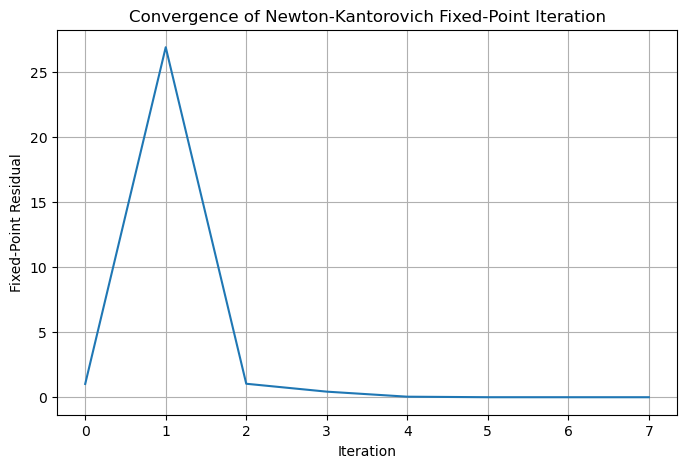

In [8]:
# Plot convergence path.
plt.figure(figsize=(8, 5))

plt.plot(errors)

plt.xlabel("Iteration")
plt.ylabel("Fixed-Point Residual")
plt.title("Convergence of Newton-Kantorovich Fixed-Point Iteration")

plt.grid(True)
plt.show() 

The convergence path exhibits a non-monotonic pattern during the initial iterations. The fixed-point residual increases sharply after the first update before declining rapidly thereafter.

This behavior is characteristic of Newton-type methods. Unlike simple fixed-point iteration, the Newton-Kantorovich algorithm does not necessarily reduce the residual at every step. Early iterations may temporarily move away from the solution while constructing a more accurate local approximation to the fixed-point mapping.

After the initial increase, the residual decreases by several orders of magnitude within only a few iterations and quickly approaches zero. The near-horizontal segment at the end of the convergence path indicates that further numerical improvements are negligible and that the fixed point has effectively been reached.

Overall, the figure demonstrates the rapid convergence of the Newton-Kantorovich algorithm and confirms the numerical stability of the benchmark solution procedure.

### 2.5.2 Benchmark Solution Objects

Solving the Rust expected value fixed-point problem produces three benchmark solution objects: the expected value function, the action-value functions, and the replacement probability function. 

The expected value function represents the fixed-point solution of the dynamic programming problem. The action-value functions evaluate the expected value associated with each feasible action, while the replacement probability function translates these action values into observable replacement behavior.

The following subsections present each benchmark solution object and its numerical properties.

**Expected Value Function**

The expected value function summarizes the expected continuation value associated with each mileage state. Following the solution of the fixed-point problem, the benchmark expected value function is obtained directly from the converged fixed-point vector $EV(x)$.

The numerical implementation is shown below.

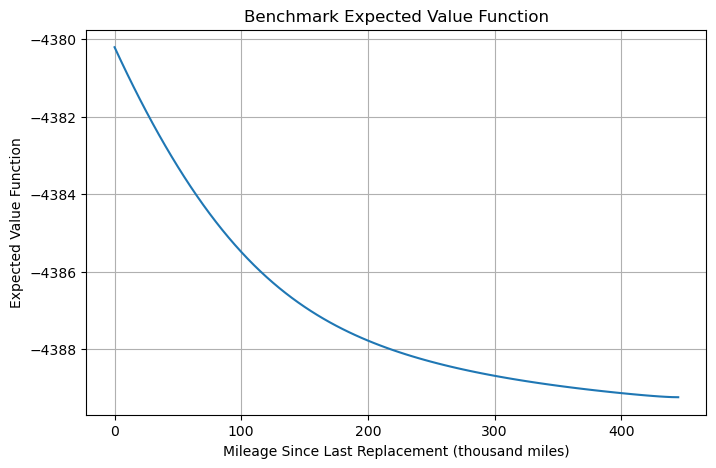

In [9]:
# Plot the benchmark expected value function using the converged fixed-point solution.
plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, EV)

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Expected Value Function")
plt.title("Benchmark Expected Value Function")

plt.grid(True)
plt.show()

The benchmark expected value function is plotted above.

The expected value function declines monotonically as mileage increases, indicating that the expected continuation value becomes progressively lower at higher mileage states.

The decline is relatively steep at low and intermediate mileage levels, while the slope gradually flattens at higher mileage levels. This pattern suggests that increases in mileage have a larger effect on expected continuation values when the engine is relatively new, whereas the marginal effect becomes smaller as mileage accumulates. The smooth and monotonic shape of the function reflects the cumulative impact of engine deterioration. Higher mileage states are associated with greater expected operating costs and therefore lower continuation values.

Overall, the figure shows that the benchmark expected value function varies systematically with mileage and provides a smooth mapping from engine condition to expected continuation value. This expected value function serves as the foundation for constructing the benchmark action-value functions and replacement probabilities examined below.

**Action-Value Functions**

The action-value functions measure the expected value associated with each feasible action at a given mileage state. Since the Rust model is formulated in utility terms, with utility defined as the negative of operating costs, higher action values correspond to more attractive decisions.

For the keep decision, $$Q(x,\text{keep})=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

For the replacement decision, $$Q(x,\text{replace})=-C(x,\text{replace})+\beta\sum_{x'}P_{\text{replace}}(x'|x)EV(x')$$

The benchmark action-value functions are constructed directly from the converged expected value function and provide an action-specific evaluation of the keep and replacement decisions.

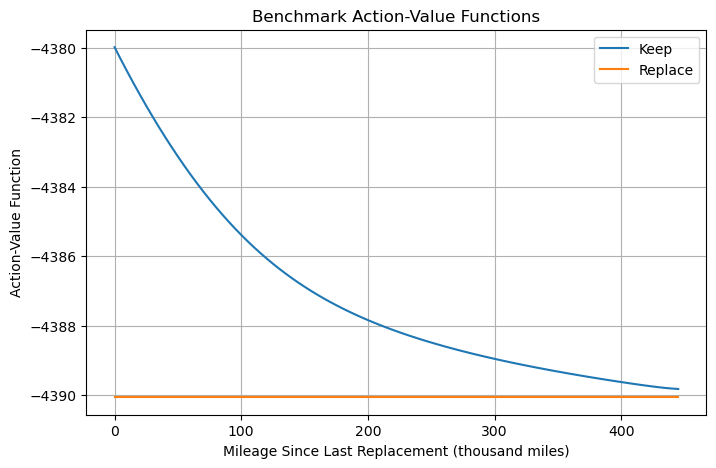

In [10]:
# Compute benchmark action-value functions using the converged expected value solution.
Q_keep = -keep_cost + beta * (P_keep @ EV)
Q_replace = -replace_cost + beta * (P_replace @ EV)

plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, Q_keep, label="Keep")
plt.plot(states * 5000 * 0.001, Q_replace, label="Replace")

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Action-Value Function")
plt.title("Benchmark Action-Value Functions")

plt.legend()
plt.grid(True)
plt.show()

The benchmark action-value functions are plotted above.

The action value associated with keeping the current engine declines steadily as mileage increases, whereas the replacement action value remains nearly constant across mileage states. As mileage accumulates, the gap between the two action-value functions becomes progressively smaller. The smallest difference occurs at the highest mileage state, where the two functions become very close but do not intersect.

The different shapes of the two functions reflect the underlying structure of the Rust model. The keep action becomes less attractive as mileage increases because higher mileage is associated with greater expected operating costs. In contrast, the replacement action value remains relatively stable because the replacement cost is fixed and replacement resets the engine condition to a low-mileage state. Consequently, replacement becomes increasingly attractive as mileage accumulates, even though the keep action continues to yield a slightly higher action value throughout the benchmark state space.

Overall, the figure shows that the relative attractiveness of the keep and replacement decisions varies systematically with mileage. The narrowing gap between the two action-value functions provides the basis for constructing the benchmark replacement probability function examined in the next section.

**Replacement Probability Function**

The replacement probability function translates the benchmark action-value functions into the probability of choosing engine replacement at each mileage state.

Under the Type-I Extreme Value assumption, the replacement probability is given by the logit choice rule $$P(\text{replace}\mid x)=\frac{\exp\left(Q(x,\text{replace})\right)}{\exp\left(Q(x,\text{keep})\right)+\exp\left(Q(x,\text{replace})\right)}$$

Similarly, the probability of keeping the current engine is $$P(\text{keep}\mid x)=\frac{\exp\left(Q(x,\text{keep})\right)}{\exp\left(Q(x,\text{keep})\right)+\exp\left(Q(x,\text{replace})\right)}$$

The replacement probability function therefore provides the behavioral implication of the benchmark action-value functions.

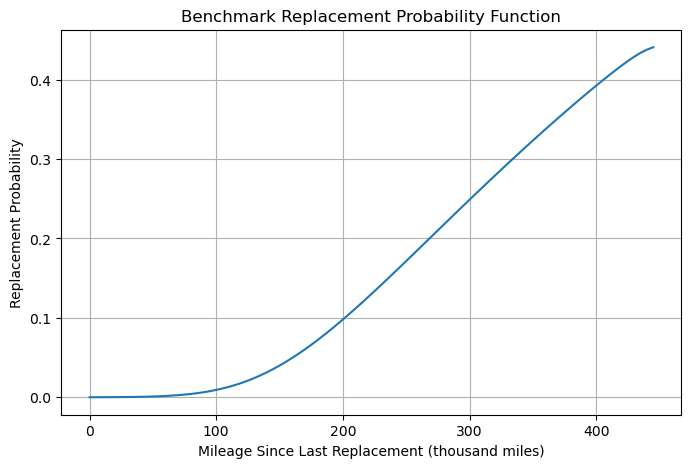

In [11]:
# Compute benchmark replacement probabilities from the action-value functions using the Rust logit choice rule.
max_Q = np.maximum(Q_keep, Q_replace)

prob_replace = np.exp(Q_replace - max_Q) / (
    np.exp(Q_keep - max_Q) + np.exp(Q_replace - max_Q)
)

plt.figure(figsize=(8, 5))

plt.plot(states * 5000 * 0.001, prob_replace)

plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Replacement Probability")
plt.title("Benchmark Replacement Probability Function")

plt.grid(True)
plt.show()

The benchmark replacement probability function is plotted above.

The replacement probability remains close to zero at low mileage levels and increases gradually as mileage accumulates. The curve becomes substantially steeper over the middle range of the state space, indicating a rapid increase in the likelihood of replacement. At very high mileage levels, the slope begins to flatten, suggesting that further mileage increases have a smaller marginal effect on replacement probability.

This nonlinear pattern arises from the logit transformation of the benchmark action-value functions. At low mileage levels, the keep action yields a substantially higher action value than replacement, resulting in replacement probabilities close to zero. As mileage increases, the gap between the keep and replacement action values narrows, causing replacement probabilities to rise more rapidly. At very high mileage levels, the two action values become relatively close, and the probability function begins to approach an upper range, producing the observed flattening of the curve.

Overall, the figure shows that replacement behavior varies systematically with engine mileage. The benchmark replacement probability function provides a smooth behavioral mapping from mileage states to replacement decisions and represents the final behavioral implication of the benchmark dynamic programming solution.

### 2.5.3 Economic Interpretation of the Benchmark Solution

The benchmark solution illustrates the fundamental economic mechanism underlying the Rust engine replacement problem. The fundamental trade-off is not between current maintenance costs and current replacement costs, but between current costs and the future consequences of today's decision.

The **expected value function** shows that engine deterioration reduces the long-run value of remaining in a given state. As mileage accumulates, future operating costs become increasingly burdensome, thereby lowering the expected continuation value associated with the current engine. The economic cost of deterioration therefore extends beyond current-period maintenance expenses and affects the entire stream of future operating outcomes.

The **action-value functions** provide a more direct view of the decision problem. Keeping the current engine allows the decision maker to avoid the immediate replacement cost, but exposes the bus to continued deterioration and higher future operating costs. Replacing the engine requires a substantial one-time expenditure, but restores the engine to a low-mileage condition and improves future operating conditions. The replacement decision therefore reflects an intertemporal comparison between preserving current resources and improving future conditions.

The **replacement probability function** illustrates how this trade-off translates into behavior. Instead of producing an abrupt switch between actions, the model produces a gradual increase in replacement likelihood as mileage accumulates. Replacement becomes progressively more attractive as deterioration worsens, but uncertainty in the decision environment implies that replacement behavior emerges as a probability rather than a deterministic rule.

Taken together, the expected value function, action-value functions, and replacement probability function provide a coherent description of the Rust dynamic decision problem. The expected value function summarizes future consequences, the action-value functions compare alternative decisions, and the replacement probability function translates these comparisons into observable behavior. Together, they illustrate how cumulative deterioration and costly renewal generate optimal replacement decisions over time and provide a quantitative characterization of the dynamic trade-off at the core of the Rust model.

# 3 The Computational Crisis of Classical Dynamic Programming

This chapter discusses the main computational bottlenecks of classical dynamic programming and reviews the major methodological developments proposed to address them. The discussion is general in scope, but the Rust bus replacement model serves as the guiding example throughout the chapter.

In general dynamic programming, the value function is the canonical solution object. In the Rust framework, however, the numerical solution is conveniently represented through the expected value fixed point. This chapter therefore uses the classical value function notation when discussing dynamic programming in general, and the expected value representation when referring specifically to the Rust benchmark and the approximation targets used in this project.

## 3.1 Computational Bottlenecks in Classical Dynamic Programming

The computational burden of the Rust framework originates from two related but distinct sources. The first arises from solving the Bellman equation itself, while the second emerges when dynamic programming is repeatedly embedded within structural estimation. These two sources form the foundation of what is often referred to as the computational crisis of classical dynamic programming.

### 3.1.1 Core Bellman Computation Bottlenecks

The Bellman equation provides the fundamental recursive representation of the Rust model. It characterizes optimal decisions through a fixed-point problem, thereby transforming a dynamic optimization problem into a computational problem.

The dynamic programming solution is characterized by a fixed-point equation. In the classical Bellman representation, this fixed point is written as $$V=T(V)$$

In practice, closed-form solutions are rarely available. The value function must therefore be computed numerically through repeated applications of the Bellman operator $$V^{(k+1)}=T\!\left(V^{(k)}\right)$$ until convergence to $V^{*}$ is achieved.

Although this recursive formulation provides a theoretically attractive characterization of optimal behavior, solving the Bellman equation requires repeated evaluations over the state space. As the complexity of the dynamic decision problem increases, several computational bottlenecks emerge that substantially increase the cost of exact dynamic programming.

#### Bottleneck 1 - Repeated Bellman Iteration

The Bellman equation transforms a dynamic optimization problem into a fixed-point problem. Although this formulation is conceptually simple, the fixed point is generally not available analytically and must instead be computed through repeated iteration.

The benchmark solution is obtained by repeatedly applying the Bellman operator $$V(x)=\max_{a\in\{0,1\}}\left\{u(x,a)+\beta\sum_{x'}P(x'|x,a)V(x')\right\}$$

The corresponding value iteration procedure is $$V^{(k+1)}=T(V^{(k)})$$

The resulting computation proceeds as $$V^{(0)}\rightarrow V^{(1)}\rightarrow V^{(2)}\rightarrow \cdots\rightarrow V^{*}$$

Each iteration requires evaluating the Bellman equation for every state in the state space. Computational cost grows with both the size of the state space and the number of iterations required for convergence. Even when convergence is guaranteed, repeated fixed-point iteration can become computationally expensive in large-scale dynamic decision problems.

#### Bottleneck 2 - Curse of Dimensionality

A more fundamental challenge arises from the dimensionality of the state space itself.

Suppose the state vector contains multiple state variables $$x=(x_1,x_2,\ldots,x_d)$$. If each dimension is discretized into $n$ grid points, the total number of states becomes $$|S|=n^d$$. For example, $$100^1 = 100$$ $$100^2 = 10,000$$ $$100^3 = 1,000,000$$

The number of states therefore grows exponentially with the number of state variables. This phenomenon is known as the curse of dimensionality.

Its implications extend beyond memory requirements. Because Bellman iteration must be evaluated at every state, exponential growth in the state space directly translates into exponential growth in computational cost. As a result, exact dynamic programming quickly becomes infeasible as additional state variables are introduced. 

#### Bottleneck 3 - Memory and State Explosion

Classical dynamic programming requires explicit storage of the value function over the entire state space.

The value function can be represented as $$V=\{V(x_1),V(x_2),\ldots,V(x_{|S|})\}$$. The memory requirement therefore scales approximately as $O(|S|)$.

In addition, dynamic programming requires storage of transition probabilities $$P=\big[P(x'|x,a)\big]$$. The number of transition elements can grow on the order of $O(|S|^2)$.

As a result, increases in state-space dimensionality generate not only computational challenges but also substantial storage requirements. In many practical applications, memory constraints become a limiting factor before Bellman iteration itself becomes the dominant computational cost. 

#### Bottleneck 4 - Numerical Stability and Convergence

Theoretical convergence does not necessarily imply computational efficiency.

Bellman iteration converges because the Bellman operator is a contraction mapping $$\|TV-TW\|\le\beta\|V-W\|$$

When the discount factor satisfies $$\beta \rightarrow 1$$ the fixed point exists and convergence is guaranteed.

In practice, as $$\beta\rightarrow1$$ the contraction becomes weaker. Successive iterations therefore generate smaller improvements, causing convergence to slow substantially.

As a result, dynamic programming problems with highly persistent future values often require many additional iterations before convergence is achieved. In large-scale environments, the resulting computational burden can become substantial even when the theoretical properties of the Bellman operator remain unchanged.

### 3.1.2 The Burden of Nested Fixed Point Estimation

The computational burden increases further when structural parameters must be estimated. In Rust's Nested Fixed Point (NFXP) framework, dynamic programming is embedded within likelihood optimization, adding another layer of computational complexity beyond the Bellman computation itself.

Structural estimation requires recovering the economic parameters that govern dynamic decision-making, such as replacement costs, maintenance costs, and discount factors. Unlike the solution of the Bellman equation, which assumes that the parameters are known, structural estimation treats these parameters as unknown and infers them from observed choices.

In the Rust framework, estimation proceeds by comparing observed decisions with the decisions implied by the dynamic programming model. 

For a given parameter vector $\theta$, the dynamic programming problem must first be solved. In classical dynamic programming this solution is often represented by the value function $V_\theta(x)$. In the Rust framework, however, the numerical solution is conveniently represented by the expected value function $EV_\theta(x)$. These solution objects then determine the choice probabilities $P(a|x;\theta)$, which can be compared with observed replacement decisions in the data.

The likelihood function measures how well the model explains the observed choices $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

Structural estimation therefore searches for the parameter vector that makes the observed decisions most likely under the model.

The estimation problem can be summarized as $$\hat{\theta}=\arg\max_{\theta}L(\theta)$$

This computational burden extends beyond the Rust model itself. The Nested Fixed Point algorithm became one of the foundational estimation methods in the dynamic discrete choice literature because it combines structural estimation with the exact solution of the underlying dynamic programming problem. However, this theoretical rigor comes at a substantial computational cost. Every parameter update requires a new solution of the Bellman equation, causing estimation time to increase rapidly as model complexity grows.

Although the NFXP framework provides a conceptually appealing estimation strategy because likelihood evaluation is based on the exact solution of the dynamic programming problem, this theoretical appeal comes at a substantial computational cost. 

For every candidate parameter vector $\theta$, the dynamic programming fixed point must first be solved before the likelihood can be evaluated. In the Rust expected value representation, this fixed point can be written as $$EV_{\theta}=T_{\theta}(EV_{\theta})$$. The resulting computational structure is therefore $$\theta\;\longrightarrow\;EV_{\theta}\;\longrightarrow\;P(a|x;\theta)\;\longrightarrow\;L(\theta)$$.

Dynamic programming is therefore nested within likelihood optimization. Every parameter update requires a new solution of the Bellman equation, causing computational costs to increase dramatically as model complexity grows.

![](../figures/nfxp_workflow.png)

#### Bottleneck 5 - Repeated Dynamic Programming within Likelihood Optimization

The defining difficulty of NFXP is that likelihood evaluation cannot be separated from the dynamic programming problem itself. 

The structural likelihood can be written as $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$

However, the choice probabilities are not directly generated by the parameter vector. Instead, they are implied by the optimal solution of the dynamic programming problem.

For a given parameter vector $\theta$, the dynamic programming fixed point must first be solved. In the expected value representation, this can be written as $$EV_{\theta}=T_{\theta}(EV_{\theta})$$. The resulting solution determines the model-implied choice probabilities $P(a|x;\theta)$, which are then used to evaluate the likelihood function. The estimation procedure therefore follows the sequence $$\theta\rightarrow EV_{\theta}\rightarrow P(a|x;\theta)\rightarrow L(\theta)$$. Whenever the parameter vector changes, $$
\theta^{(1)}\rightarrow EV^{(1)},\qquad
\theta^{(2)}\rightarrow EV^{(2)},\qquad
\theta^{(3)}\rightarrow EV^{(3)},
$$
the dynamic programming problem must be solved again.

The computational burden arises primarily not because solving a single Bellman equation is necessarily difficult, but because the Bellman equation must be solved repeatedly throughout the optimization procedure. Even relatively small parameter updates require a new value-function solution and a new likelihood evaluation.

The computational challenge shifts from solving one dynamic programming problem to repeatedly solving many closely related dynamic programming problems during estimation. This nested structure is the defining characteristic of the NFXP algorithm and one of the primary reasons why structural dynamic models became computationally demanding.

#### Bottleneck 6 - Computational Scaling of Structural Estimation

The computational burden of NFXP grows multiplicatively because dynamic programming and likelihood optimization are nested within one another.

Let $N_V$ denote the number of Bellman iterations required to solve the value function. Let $N_{\theta}$ denote the number of likelihood evaluations required during estimation. The overall computational burden can be approximated by $$O(N_{\theta}N_V|S|)$$

Unlike the Bellman problem alone, structural estimation must simultaneously account for all three dimensions of complexity.

An increase in the size of the state space $$|S|\uparrow$$ raises the computational cost of each Bellman iteration. An increase in model complexity often increases the number of iterations required for convergence $$N_V\uparrow$$ Similarly, a larger parameter space generally requires more likelihood evaluations during optimization $$N_{\theta}\uparrow$$

The implication is that these sources of complexity do not operate independently. Because they interact through the nested structure of the estimation problem, computational costs can increase much faster than suggested by any individual component.

For relatively simple models, the resulting burden may remain manageable. However, as researchers introduce additional state variables, richer transition dynamics, or more flexible behavioral specifications, estimation costs can grow rapidly. In many applications, solving the dynamic programming problem is no longer the primary challenge; the challenge becomes solving it repeatedly inside a large-scale optimization routine.

This scaling problem motivated subsequent methodological developments. Some approaches attempted to reduce the need for repeated Bellman solutions during estimation, while others sought more efficient ways to represent and compute Bellman-based solution objects themselves.

## 3.2 Historical Responses to the Computational Crisis of Dynamic Programming 

The computational limitations of classical dynamic programming motivated extensive methodological developments aimed at reducing the cost of solving and estimating dynamic decision models. Over time, two broad routes emerged. One line of research focused on reducing the computational burden of structural estimation, whereas the other sought more efficient ways to approximate Bellman-based solutions within the dynamic programming framework.

![](../figures/historical_tree.png)

### 3.2.1 Econometric Route 

The econometric route seeks to reduce the computational burden of structural estimation by avoiding repeated solutions of the Bellman equation.

Under the original Nested Fixed Point framework, each parameter update requires solving the fixed point $$V_{\theta}=T_{\theta}(V_{\theta})$$, before evaluating the likelihood function $$L(\theta)=\prod_{i=1}^{N}\prod_{t=1}^{T}P(a_{it}\mid x_{it};\theta)$$ or equivalently the log-likelihood $$\ell(\theta)=\sum_{i=1}^{N}\sum_{t=1}^{T}\log P(a_{it}\mid x_{it};\theta)$$ 

The computational objective becomes $$\min\Big(\text{Number of Bellman Solves}\Big)$$ 

Instead of repeatedly solving the dynamic programming problem, econometric approaches attempt to recover structural information through alternative representations of the decision process.

#### Conditional Choice Probability Methods 

Conditional Choice Probability (CCP) methods were developed to reduce the computational burden associated with repeatedly solving the Bellman equation during structural estimation. 

CCP methods are based on the observation that  observed choice probabilities contain information about the underlying value function. Rather than solving the dynamic programming problem for every parameter vector, CCP methods exploit the relationship between observed decisions and continuation values. 

Let $$P(a|x)=\Pr(a_t=a\mid x_t=x)$$ 

Under suitable assumptions, these probabilities can be linked to differences in choice-specific value functions $$Q(x,a)=u(x,a)+\beta E[V(x')|x,a]$$ 

Hotz and Miller (1993) showed that a one-to-one mapping exists between conditional choice probabilities and value-function differences $$P(a|x)\Longleftrightarrow Q(x,a)-Q(x,a')$$ 

Portions of the dynamic programming problem can be recovered through inversion of observed choice probabilities rather than through repeated Bellman iteration. 

The main advantage of CCP methods is computational efficiency. By replacing repeated value-function solutions with probability inversion, structural estimation becomes substantially faster. 

However, the approach does not eliminate the dynamic programming structure itself. Accurate estimation still requires reliable estimates of conditional choice probabilities, and the method becomes increasingly difficult in environments with large action spaces, sparse observations, or high-dimensional state variables. 

#### Mathematical Programming Approaches 

Another branch of the econometric route reformulates the estimation problem itself rather than modifying the underlying dynamic model. The most influential example is Mathematical Programming with Equilibrium Constraints (MPEC). 

Under Rust's Nested Fixed Point algorithm, parameter estimation requires solving $$V_{\theta}=T_{\theta}(V_{\theta})$$ for every candidate parameter vector before evaluating the likelihood function $L(\theta)$ MPEC removes this nested structure by treating the value function as an optimization variable. 

The estimation problem becomes $$\max_{\theta,V}L(\theta,V)$$ 

subject to $$V=T_{\theta}(V)$$ 

The Bellman equation therefore appears as an equilibrium constraint rather than as an inner optimization problem. This reformulation reduces the computational cost associated with repeated Bellman solutions and allows modern nonlinear optimization algorithms to be applied directly. 

Even so, the Bellman equation remains part of the estimation problem. As the state space grows, the number of equilibrium constraints increases rapidly, which can generate large-scale constrained optimization problems that remain computationally demanding. 

#### Simulation-Based Methods 

Simulation-based methods address the computational burden of evaluating expectations that arise in dynamic programming and structural estimation. 

Many dynamic decision models require the computation of expected continuation values of the form $$E[V(x')]=\int V(x')p(x'|x,a)dx'$$ 

When the state space is large or the transition process is complex, evaluating this expectation exactly can become computationally expensive. 

Simulation methods replace analytical integration with simulated draws $$E[V(x')]\approx\frac{1}{N}\sum_{i=1}^{N}V(x'_i),\qquad x'_i\sim p(x'|x,a)$$ 

Their main advantage is flexibility. Simulation methods can accommodate complicated transition dynamics, latent variables, and high-dimensional stochastic processes that are difficult to integrate analytically.

However, simulation introduces sampling noise. Accuracy depends on the number of simulated observations, and computational costs may increase substantially when high precision is required. Simulation often replaces one computational problem with another: exact integration is avoided, but a large number of simulations may be needed to obtain stable estimates.

### 3.2.2 Computational Route 

The computational route developed from a different perspective on the computational crisis of dynamic programming. Rather than reducing the burden of structural estimation, this literature focuses on reducing the cost of representing and computing Bellman-based solution objects themselves. 

Instead of avoiding the fixed-point problem, the objective of the computational route is to approximate the main solution objects generated by dynamic programming more efficiently.

In classical dynamic programming, these objects are often represented by value functions, action-value functions, or policy functions. In the Rust framework, however, the expected value representation provides a convenient alternative fixed-point formulation.

Accordingly, the present study focuses on three Rust solution objects: $$
EV_{\theta}(x),\quad
Q_{\theta}(x,a),\quad
P_{\theta}(a|x)
$$
Here, $EV_{\theta}(x)$ denotes the expected value function, $Q_{\theta}(x,a)$ denotes the action-value function, and $P_{\theta}(a|x)$ denotes the model-implied choice probability.

These objects are linked through the Rust expected value structure: $$Q_{\theta}(x,a)=u_{\theta}(x,a)+\beta\sum_{x'}F_{\theta}(x'|x,a)EV_{\theta}(x')$$. Under the Type-I Extreme Value assumption, the action-value functions imply choice probabilities through the logit rule $$P_{\theta}(a|x)=\frac{\exp(Q_{\theta}(x,a))}{\sum_{a'}\exp(Q_{\theta}(x,a'))}$$.

These solution objects become increasingly difficult to store, compute, and evaluate as the state space expands. Consequently, the computational route focuses on finding more efficient representations of Bellman solutions rather than modifying the estimation procedure itself. 

Over time, the computational route evolved through several generations of approximation methods, reflecting a gradual shift from manually designed representations to increasingly data-driven approaches.

These stages should not be viewed as mutually exclusive replacements. Classical approximation methods, statistical learning techniques, and deep learning approaches all remain active areas of research and continue to be used in different dynamic programming applications depending on the dimensionality, computational requirements, and interpretability objectives of the problem.

#### Classical Function Approximation 

The earliest computational responses to the Bellman equation relied on manually specified functional representations of the value function. 

Rather than storing a value for every state on a discrete grid, $V(x)$ the value function is approximated by a finite set of basis functions $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ where $\phi_k(x)$ denotes predetermined basis functions and $w_k$ are coefficients to be estimated. 

Representative approaches include interpolation methods, projection methods, polynomial approximations, and other basis-function techniques. The main advantage of this approach is dimensional reduction. Instead of storing and updating values at every point in the state space, dynamic programming is performed on a relatively small set of coefficients. These methods remain widely used because they are computationally efficient, theoretically transparent, and often provide good approximations in low-dimensional settings.  

Its performance, however, depends heavily on the choice of basis functions. As state spaces become larger and more nonlinear, manually designed functional forms often become difficult to construct and may fail to capture complex value-function shapes. 

#### Learning-Based Function Approximation 

As dynamic decision models became larger and more complex, researchers increasingly moved beyond manually specified basis functions and adopted data-driven approximation methods. 

Under classical function approximation, the researcher first selects a functional representation $$V(x)\approx\sum_{k=1}^{K}w_k\phi_k(x)$$ and then estimates the coefficients $w_k$. 

The quality of the approximation therefore depends heavily on the choice of basis functions $\phi_k(x)$. 

When the underlying value function exhibits strong nonlinearities or when the state space becomes large, manually designing appropriate basis functions becomes increasingly difficult. 

Learning-based function approximation addresses this limitation by treating the representation itself as part of the learning problem. Instead of specifying the functional form in advance, the approximation is learned directly from data $$V(x)\approx f(x;\theta)$$ where $\theta$ denotes parameters estimated from simulated or observed data. 

The conceptual shift is that approximation no longer relies primarily on economic intuition regarding functional forms. Instead, the representation is inferred from data and optimized according to predictive performance. 

This transition represented an important development in approximate dynamic programming. It expanded the range of functions that could be represented and reduced the dependence on manually designed basis functions. However, it introduced a new challenge: the quality of the approximation now depends on the learning algorithm, the available data, and the statistical properties of the estimator. 

##### Statistical and Machine Learning Approximation 

The first generation of learning-based approximation methods relied on statistical and machine learning techniques to estimate dynamic programming solution objects from data.

Rather than solving the Bellman equation on a complete state grid, these methods approximate the mapping $$x\longrightarrow V(x)$$ using statistical models estimated from Bellman targets. 

A generic approximation problem can be written as $$V(x)\approx f(x;\theta)$$ where $f(\cdot)$ may represent a regression model, a decision tree, a kernel estimator, or another statistical learning procedure. 

Representative methods include: 
- Fitted Value Iteration - Regression-Based Approximation
- Tree Methods
- Kernel Methods

For example, fitted value iteration repeatedly constructs Bellman targets $$y_i=T(V^{(m)})(x_i)$$ and estimates $$f(x;\theta)$$ through statistical regression $$\arg\min_{\theta}\sum_{i=1}^{N}\left(y_i-f(x_i;\theta)\right)^2$$ 

Relative to classical function approximation, these methods substantially increase flexibility because the approximation is learned from data rather than imposed through predetermined basis functions.  

However, most statistical learning methods remain relatively shallow. Their performance often depends on feature engineering and the selection of appropriate model structures. As the dimensionality of the state space increases, accurately representing highly nonlinear value functions can become increasingly difficult. 

These methods remain widely used today. In many applications they provide an attractive compromise between computational efficiency, interpretability, and approximation accuracy. 

##### Deep Learning Approximation 

Deep learning extends the learning-based approximation paradigm by employing multi-layer neural networks as flexible nonlinear function approximators. Instead of relying on manually constructed features or shallow statistical models, deep neural networks learn hierarchical representations directly from data. 

A neural network can be used to approximate different dynamic programming solution objects. 

For example, $$
EV(x)\approx EV_{\theta}(x),\qquad
Q(x,a)\approx Q_{\theta}(x,a),\qquad
P(a|x)\approx P_{\theta}(a|x).
$$

The specific object being approximated depends on the learning objective and the structure of the approximation method.

Deep learning is distinguished by its ability to learn representations automatically. Rather than specifying the features used for approximation, the network learns multiple layers of nonlinear transformations that are optimized jointly during training. 

Relative to earlier statistical learning methods, deep learning substantially increases representational capacity. Neural networks are therefore particularly attractive in dynamic decision problems characterized by high-dimensional state spaces, complex nonlinearities, and large-scale simulation environments. 

Within dynamic programming, deep learning approaches can be organized along several dimensions. 

**By Approximation Target** 

The first classification concerns which object generated by dynamic programming is approximated. 

- Expected Value Function Approximation $EV(x)\approx EV_{\theta}(x)$
- Action-Value Function Approximation $Q(x,a)\approx Q_{\theta}(x,a)$
- Choice Probability Approximation $P(a|x)\approx P_{\theta}(a|x)$

These targets correspond to different components of the Bellman framework and may imply different computational trade-offs. The present study focuses on these three approximation targets within the Rust framework.

**By Learning Paradigm** 

A second classification concerns how learning takes place. 

In Deep Reinforcement Learning, neural networks are trained using simulated or observed trajectories $(x_t,a_t,r_t,x_{t+1})$ and learning is guided by Bellman-consistent targets such as $$r_t+\beta\max_{a'}Q_{\theta}(x_{t+1},a')$$ 

The objective is to learn dynamic solution objects, such as value functions, action-value functions, or choice rules, directly from interactions with the environment. 

**By Equilibrium Structure** 

A third classification concerns fixed-point representations. 

Classical dynamic programming seeks a solution to $$V=T(V)$$. Deep Equilibrium Networks instead learn an implicit fixed-point representation $$z^*=F_\theta(z^*,x)$$ where the equilibrium state is obtained as the solution of a learned fixed-point equation rather than through explicit iterative computation.

The principal advantage of deep learning is scalability. Neural networks can represent highly complex nonlinear relationships without explicitly specifying basis functions or handcrafted features. 

These advantages, however, come at a cost. Approximation error remains unavoidable, convergence guarantees are generally weaker than those available in classical dynamic programming, and the resulting representations may be more difficult to interpret economically. Furthermore, performance often depends on architectural choices, optimization procedures, and hyperparameter selection. 

For these reasons, deep learning should not be viewed as a replacement for earlier approximation methods. Instead, it represents the most recent stage in a broader historical evolution of approximation techniques, complementing rather than eliminating classical and statistical approaches.

# 4 Assessment of Alternative Neural Learning Targets in the Rust Model 

The numerical solution of the Rust model produces several related solution objects that can potentially serve as neural learning targets. This chapter evaluates the expected value function, the action-value function, and the replacement probability function from both theoretical and computational perspectives. The chapter aims to identify the most suitable learning target within the Rust framework.

## 4.1 Conceptual Assessment of Alternative Learning Targets

The Rust benchmark solution produces several related solution objects that differ in their role within the dynamic decision process. This section provides a conceptual assessment of the expected value function, the action-value function, and the replacement probability function as alternative targets for neural approximation. 

**Candidate Learning Targets**

The Rust benchmark solution generates a sequence of related solution objects rather than a single numerical output. The expected value function is obtained as the fixed point of the solution procedure, action-value functions are constructed from the expected value function, and replacement probabilities are subsequently determined through the logit choice rule.

The Rust solution structure can be represented as $$
EV^*(x)
\;\longrightarrow\;
Q^*(x,a)
\;\longrightarrow\;
P^*(replace \mid x)
$$

These objects correspond to different layers of the same dynamic decision problem. The expected value function serves as the continuation-value representation of the model, the action-value function translates continuation values into action-specific decision values, and the replacement probability function summarizes the resulting policy outcome.

As information is progressively transformed along this sequence, approximating different objects may preserve different amounts of the underlying Rust solution structure. The suitability of these objects as neural approximation targets is therefore not necessarily equivalent and requires further assessment.

**Comparison Framework**

Their suitability is assessed from four dimensions: 
1. Dynamic Programming Relevance
2. Information Content
3. Behavioral Interpretability
4. Suitability for Deeper Approximation

| Target | Dynamic Structure | Decision Information | Behavioral Interpretation | Suitability for Chapter 5 |
|---|---|---|---|---|
| Expected Value Function $$EV^*(x)$$ | Direct fixed-point object | Full continuation-value information | Relatively abstract | Very High |
| Action-Value Function $$Q^*(x,a)$$ | Derived decision-value object | Rich action-level information | Moderate | High |
| Replacement Probability $$P^*(replace \mid x)$$ | Policy outcome | Compressed decision information | High | Low to Moderate |

**Theoretical Assessment**

From the perspective of **dynamic programming relevance**, the expected value function is the closest object to the numerical solution procedure of the Rust model. Value function iteration directly searches for the fixed point of the expected value representation, making the expected value function the central object of the computation. The action-value function also remains closely connected to the Bellman structure because it is constructed from continuation values. The replacement probability is further removed from the solution procedure, as it is generated only after action values have been compared. 

The three targets further differ in terms of **information content**. The expected value function contains the continuation-value information that governs future payoffs and state transitions. The action-value function preserves most of this information while additionally separating the values associated with individual actions. In contrast, the replacement probability summarizes only the final decision outcome. Different combinations of action values may produce similar replacement probabilities, implying a loss of information relative to the expected value and action-value representations.

**Behavioral interpretability** follows the opposite pattern. The replacement probability directly describes replacement behavior and is therefore the most intuitive object from an economic perspective. The action-value function provides insight into the trade-off between keeping and replacing the engine. The expected value function is less directly interpretable because it represents continuation values rather than observable decisions.

Finally, the three targets differ in their usefulness for **deeper approximation tasks**. Because the objective of neural approximation is not only to reproduce behavior but also to approximate the underlying solution structure, objects that remain closer to the Rust fixed-point representation may provide greater flexibility for subsequent extensions. From this perspective, the expected value function and the action-value function appear to offer richer foundations for approximation than the replacement probability function.

**Theoretical Expectation**

Overall, the theoretical assessment suggests a trade-off among the three candidates.

The expected value function and the action-value function retain a richer representation of the Rust solution structure, whereas the replacement probability function provides a more direct behavioral representation but contains less information about the underlying dynamic decision problem.

On theoretical grounds alone, the expected value function and the action-value function therefore appear to be stronger candidates for neural approximation. However, theoretical analysis alone does not clearly distinguish between these two representations. Their relative suitability remains an empirical question and is examined in the screening experiment.

## 4.2 Screening Experiment of Alternative Learning Targets  

Theoretical considerations alone cannot establish how effectively these objects can be approximated by neural networks. This section conducts a screening experiment under a unified setting to evaluate neural approximation of the expected value function, the action-value function, and the replacement probability function.

The screening experiment is not designed to solve the Rust model using neural networks. Benchmark solution objects are first obtained from the classical Rust solution procedure and then treated as learning targets. Neural networks are then trained to approximate the mapping from mileage states to these benchmark targets. The experiment therefore evaluates **supervised neural function approximation** rather than neural solution of the dynamic programming problem itself.

### 4.2.1 Screening Experiment Design 

To ensure a fair comparison across learning targets, all neural network models are trained under the same experimental setting. The only difference lies in the learning object. 

For each candidate target, the corresponding benchmark targets are generated from the Rust benchmark solution for bus group 4. The same 90 mileage states are used as inputs for all experiments, while the benchmark targets correspond to the expected value function, the action-value function, or the replacement probability function.

The approximation problem can be written as $x \longrightarrow \hat{f}(x;\theta)$, where $x$ denotes the mileage state and $\hat{f}(x;\theta)$ denotes the neural network approximation of the selected learning object.

**Network Architecture**

| Component | Setting |
|----------|----------|
| Network Type | Fully Connected Feedforward |
| Hidden Layers | 2 |
| Hidden Units | 32 per Layer |
| Activation Function | ReLU |
| Output Layer | Linear |
| Action-Value Output | Two Outputs (Keep, Replace) |
| Expected Value Output | One Output |
| Replacement Probability Output | One Output |

All candidate targets are approximated using the same neural network architecture. Only the output dimension differs according to the selected learning target.

**Experimental Environment**

| Component | Setting |
|----------|----------|
| Model Environment | Rust Bus Replacement Model |
| Bus Group | Group 4 |
| Benchmark Source | Classical Rust Benchmark Solution |
| State Space | 90 Mileage States |
| Input Variable | Mileage State $x$ |
| Candidate Targets | Expected Value Function; Action-Value Function; Replacement Probability Function |
| Training Sample | Full Set of 90 Benchmark Mileage States |
| Train-Test Split | No Split (Full Benchmark Grid) |

The use of the same benchmark environment for all candidate targets ensures that differences in approximation performance arise from the learning target itself rather than from differences in the underlying data.

**Training Hyperparameters**

| Component | Setting |
|----------|----------|
| Learning Task | Supervised Function Approximation |
| Loss Function | Mean Squared Error |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Epochs | 1000 |
| Batch Size | Full-Batch Training |
| Random Seed | Fixed Across All Experiments |
| Implementation | PyTorch |

These settings provide the baseline configuration for all target approximation experiments, ensuring that performance differences are attributable to the selected learning target rather than differences in training configuration.

**Network Architecture**

All candidate targets are approximated using the same neural network architecture:
```text
Input Layer
      ↓
Hidden Layer (32 ReLU)
      ↓
Hidden Layer (32 ReLU)
      ↓
Output Layer
```

The network architecture remains identical across all experiments. Only the output dimension changes according to the learning object. The expected value function and replacement probability function use a single-output network, whereas the action-value function uses two outputs corresponding to the keep and replace action values.

The architecture is intentionally simple. The Rust benchmark contains a one-dimensional state variable and only 90 mileage states. A small fully connected feedforward network is therefore sufficient to capture the underlying functional relationships while avoiding unnecessary model complexity.

Using the same architecture for all candidate targets ensures that differences in approximation performance are attributable to the learning object itself rather than differences in network capacity. Since the purpose of the screening experiment is target evaluation rather than model optimization, a compact and transparent architecture provides a more appropriate basis for comparison.

All benchmark states are used during training because the objective is to evaluate approximation performance on the solved Rust state space rather than predictive generalization beyond the benchmark grid.

### 4.2.2 Screening Evaluation Criteria

**Approximation Accuracy**

Approximation accuracy is evaluated using both target-specific and cross-target measures.

The **target-specific measure** is mean squared error. It evaluates how accurately the neural network approximates each learning target.

- For the expected value function, $$MSE_{EV}=\frac{1}{N}\sum_{i=1}^{N}\left(EV_i^{Benchmark}-EV_i^{Predicted}\right)^2$$
- For the action-value function, the network approximates both the keep and replace action values. The error is therefore averaged over both action-specific outputs: $$MSE_{Q}=\frac{1}{2N}\sum_{i=1}^{N}\left[\left(Q_{i,keep}^{Benchmark}-Q_{i,keep}^{Predicted}\right)^2+\left(Q_{i,replace}^{Benchmark}-Q_{i,replace}^{Predicted}\right)^2\right]$$
- For the replacement probability function, $$MSE_{P}=\frac{1}{N}\sum_{i=1}^{N}\left(P_i^{Benchmark}-P_i^{Predicted}\right)^2$$

Lower MSE values indicate more accurate approximation of the corresponding learning object.

The **cross-target measure** is normalized root mean squared error. Since the expected value function, the action-value function, and the replacement probability function have different numerical scales, raw MSE values are not directly comparable across targets. NRMSE normalizes the root mean squared error by the range of the benchmark target values: $$NRMSE=\frac{\sqrt{MSE}}{\max(y^{Benchmark})-\min(y^{Benchmark})}$$

For the action-value function, the normalization range is computed over both benchmark action-value series: $$\max(y^{Benchmark})-\min(y^{Benchmark})=\max(Q_{keep}^{Benchmark},Q_{replace}^{Benchmark})-\min(Q_{keep}^{Benchmark},Q_{replace}^{Benchmark})$$

The corresponding normalized errors are $$
NRMSE_{EV}, \qquad
NRMSE_{Q}, \qquad
NRMSE_{P}
$$

MSE indicates how accurately the network approximates each target. NRMSE enables comparison across targets after controlling for scale differences.

**Learning Behavior Assessment**

Approximation error alone does not reveal whether the neural network preserves the structure of the benchmark object. Graphical inspection is used to assess whether the approximation retains the key theoretical patterns implied by the Rust solution.

- For the expected value function, the assessment focuses on whether the predicted curve preserves the overall shape and monotonic pattern of the benchmark expected value function.
- For the action-value function, the assessment examines whether the predicted keep and replace values preserve the relationship between the two benchmark action-value curves, including the variation in the value gap across mileage states.
- For the replacement probability function, the assessment evaluates whether the predicted probability curve reproduces the increasing and S-shaped pattern implied by the benchmark solution.

This qualitative assessment complements the numerical error measures by focusing on structural preservation rather than accuracy alone.

### 4.2.3 Screening Evaluation Results 

This section reports the neural approximation results for each candidate learning target under the common experimental setting described above. For each target, approximation performance is evaluated using MSE, NRMSE, and graphical comparisons between benchmark values and neural network predictions.

#### Expected Value Function Learning

The first screening experiment uses the benchmark expected value function as the neural approximation target: $$Target = EV^*(x)$$

The neural network maps mileage states into predicted expected values: $$x\longrightarrow EV\ Network\longrightarrow\widehat{EV}(x)$$

Approximation accuracy is evaluated using MSE and NRMSE. Learning behavior is assessed by comparing the benchmark and predicted expected value functions.

The implementation of the neural approximation is shown below.

Target: Expected Value Function
MSE_EV = 0.0010808388
NRMSE_EV = 0.003638688


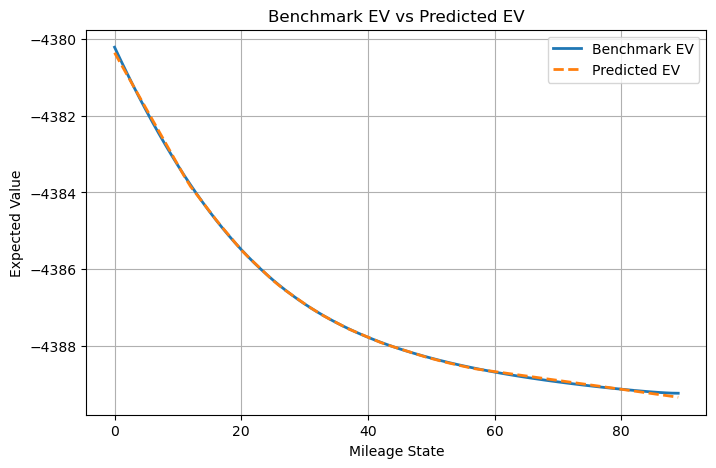

In [12]:
# Neural Approximation: Mileage State -> EV Network -> Predicted EV
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Prepare Training Data

# Input: mileage state
x_ev = np.asarray(states, dtype=np.float32).reshape(-1, 1)

# Target: benchmark expected value function
y_ev = np.asarray(EV, dtype=np.float32).reshape(-1, 1)

# Normalize input
x_ev_min = x_ev.min()
x_ev_max = x_ev.max()
x_ev_norm = (x_ev - x_ev_min) / (x_ev_max - x_ev_min)

# Normalize target
y_ev_mean = y_ev.mean()
y_ev_std = y_ev.std()
y_ev_norm = (y_ev - y_ev_mean) / y_ev_std

X_ev = torch.tensor(x_ev_norm, dtype=torch.float32)
Y_ev = torch.tensor(y_ev_norm, dtype=torch.float32)

# 2. Neural Network Architecture

torch.manual_seed(123)
np.random.seed(123)

class ScreeningNetwork(nn.Module):
    def __init__(self, output_dim=1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.network(x)

# EV network uses one output
ev_model = ScreeningNetwork(output_dim=1)

# 3. Training Setup

criterion = nn.MSELoss()
optimizer = optim.Adam( ev_model.parameters(), lr=0.001)
epochs = 1000
ev_loss_history = []

# 4. Train EV Network

for epoch in range(epochs):
    ev_model.train()
    optimizer.zero_grad()
    y_pred = ev_model(X_ev)
    loss = criterion(y_pred, Y_ev)
    loss.backward()
    optimizer.step()
    ev_loss_history.append(loss.item())

# 5. Generate Predicted EV

ev_model.eval()
with torch.no_grad():
    EV_predicted_norm = ev_model(X_ev).numpy()

# Convert back to original EV scale
EV_predicted = (EV_predicted_norm * y_ev_std + y_ev_mean)
EV_predicted = EV_predicted.reshape(-1)

# Benchmark values
EV_benchmark = y_ev.reshape(-1)

# 6. Approximation Accuracy

MSE_EV = np.mean((EV_benchmark - EV_predicted) ** 2)
NRMSE_EV = (np.sqrt(MSE_EV) / (np.max(EV_benchmark) - np.min(EV_benchmark)))

print("Target: Expected Value Function")
print("MSE_EV =", MSE_EV)
print("NRMSE_EV =", NRMSE_EV)

# 7. Learning Behavior Assessment

plt.figure(figsize=(8,5))
plt.plot(
    states,
    EV_benchmark,
    linewidth=2,
    label="Benchmark EV"
)
plt.plot(
    states,
    EV_predicted,
    "--",
    linewidth=2,
    label="Predicted EV"
)
plt.xlabel("Mileage State")
plt.ylabel("Expected Value")
plt.title("Benchmark EV vs Predicted EV")
plt.legend()
plt.grid(True)
plt.show()

**Learning Behavior**

The benchmark expected value function and the neural network prediction are plotted above.

The predicted curve follows the benchmark function closely throughout the state space and preserves its overall downward trend. The continuation value decreases as mileage increases, and this monotonic relationship is retained by the neural approximation.

Some differences are nevertheless visible near the lower and upper ends of the mileage range. Relative to the benchmark solution, the neural network prediction appears slightly smoother, producing a less pronounced curvature at the boundaries of the state space. These deviations suggest that the approximation does not reproduce every local feature of the benchmark function perfectly.

Despite these differences, the overall shape of the expected value function is preserved. The neural network captures the main continuation-value pattern implied by the Rust solution and provides a close approximation of the benchmark object. 

#### Action-Value Function Learning

The second screening experiment uses the benchmark action-value functions as the neural approximation target: $$Target = Q^*(x,a)$$

The neural network maps mileage states into predicted keep and replace action values: $$x\longrightarrow Q\ Network\longrightarrow\left(\widehat{Q}_{keep}(x),\widehat{Q}_{replace}(x)\right)$$

Unlike the expected value experiment, the action-value network contains two outputs corresponding to the keep and replace actions.

Approximation accuracy is evaluated using MSE and NRMSE. Learning behavior is assessed by comparing the benchmark and predicted action-value functions.

The implementation of the neural approximation is shown below.

Target: Action-Value Function
MSE_Q = 0.0004707810749008571
NRMSE_Q = 0.002153597028281152


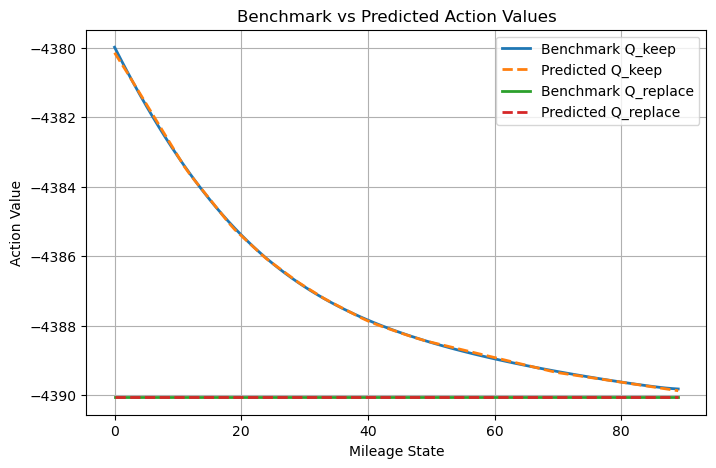

In [13]:
# Neural Approximation: Mileage State -> Q Network -> Predicted Q_keep, Predicted Q_replace

# 1. Prepare Training Data

# Input: mileage state
x_q = np.asarray(states, dtype=np.float32).reshape(-1, 1)

# Targets: benchmark action-value functions
y_q = np.column_stack([Q_keep, Q_replace]).astype(np.float32)

# Normalize input
x_q_min = x_q.min()
x_q_max = x_q.max()
x_q_norm = (x_q - x_q_min) / (x_q_max - x_q_min)

# Normalize targets
y_q_mean = y_q.mean(axis=0)
y_q_std = y_q.std(axis=0)
y_q_norm = (y_q - y_q_mean) / y_q_std

X_q = torch.tensor(x_q_norm, dtype=torch.float32)
Y_q = torch.tensor(y_q_norm, dtype=torch.float32)

# 2. Q Network

torch.manual_seed(123)
np.random.seed(123)

q_model = ScreeningNetwork(output_dim=2)

# Neural network architecture defined in the expected value function experiment.
# 3. Training Setup

criterion = nn.MSELoss()
optimizer = optim.Adam(q_model.parameters(), lr=0.001)
epochs = 1000
q_loss_history = []

# 4. Train Q Network

for epoch in range(epochs):
    q_model.train()
    optimizer.zero_grad()
    y_pred = q_model(X_q)
    loss = criterion(y_pred, Y_q)
    loss.backward()
    optimizer.step()
    q_loss_history.append(loss.item())

# 5. Generate Predicted Q

q_model.eval()
with torch.no_grad():
    Q_pred_norm = (q_model(X_q).numpy())

# Convert back to original scale
Q_pred = (Q_pred_norm * y_q_std + y_q_mean)
Q_keep_pred = Q_pred[:, 0]
Q_replace_pred = Q_pred[:, 1]

# Benchmark values
Q_keep_benchmark = np.asarray(Q_keep)
Q_replace_benchmark = np.asarray(Q_replace)

# 6. Approximation Accuracy

MSE_Q = np.mean(np.concatenate([(Q_keep_benchmark - Q_keep_pred) ** 2, (Q_replace_benchmark - Q_replace_pred) ** 2]))
Q_all = np.concatenate([Q_keep_benchmark, Q_replace_benchmark])
NRMSE_Q = (np.sqrt(MSE_Q) / (np.max(Q_all) - np.min(Q_all)))

print("Target: Action-Value Function")
print("MSE_Q =", MSE_Q)
print("NRMSE_Q =", NRMSE_Q)

# 7. Learning Behavior Assessment

plt.figure(figsize=(8,5))
plt.plot(
    states,
    Q_keep_benchmark,
    linewidth=2,
    label="Benchmark Q_keep"
)
plt.plot(
    states,
    Q_keep_pred,
    "--",
    linewidth=2,
    label="Predicted Q_keep"
)
plt.plot(
    states,
    Q_replace_benchmark,
    linewidth=2,
    label="Benchmark Q_replace"
)
plt.plot(
    states,
    Q_replace_pred,
    "--",
    linewidth=2,
    label="Predicted Q_replace"
)
plt.xlabel("Mileage State")
plt.ylabel("Action Value")
plt.title("Benchmark vs Predicted Action Values")
plt.legend()
plt.grid(True)
plt.show()

**Learning Behavior**

The benchmark and predicted action-value functions are plotted above.

The neural network preserves the key structural features of the benchmark action-value representation. The predicted keep value closely follows the benchmark keep value across the entire mileage-state space, while the predicted replace value remains nearly identical to the benchmark replace value.

The relationship between the two action values is also preserved. As mileage increases, the keep value declines steadily whereas the replace value remains approximately constant. Consequently, the gap between the two action values narrows with mileage in both the benchmark solution and the neural approximation.

Only very small differences are visible between benchmark and predicted values. The close agreement suggests that the neural network successfully captures both the individual action values and the decision structure implied by their relative magnitudes.

#### Replacement Probability Learning

The third screening experiment uses the benchmark replacement probability function as the neural approximation target: $$Target = P^*(replace|x)$$

The neural network maps mileage states into predicted replacement probabilities: $$x\longrightarrow Probability\ Network\longrightarrow\widehat{P}(replace|x)$$

Approximation accuracy is evaluated using MSE and NRMSE. Learning behavior is assessed by comparing the benchmark and predicted replacement probability functions.

The implementation of the neural approximation is shown below.

Target: Replacement Probability Function
MSE_P = 4.8484515e-07
NRMSE_P = 0.0015793714


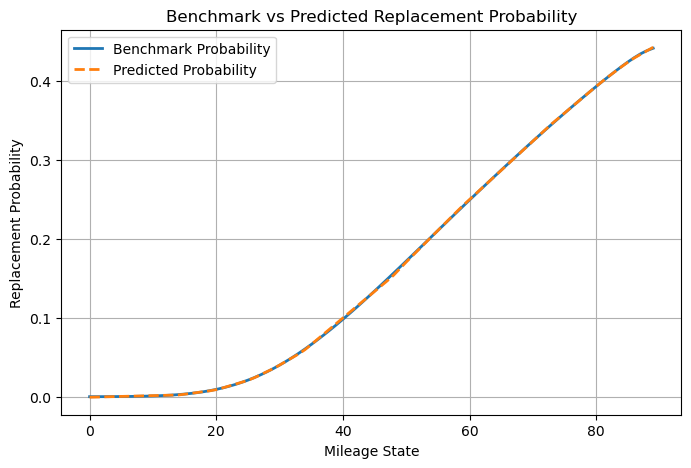

In [14]:
# Neural Approximation: Mileage State -> Probability Network -> Predicted Probability

# 1. Prepare Training Data

# Input: mileage state
x_p = np.asarray(states, dtype=np.float32).reshape(-1, 1)

# Target: benchmark replacement probability
y_p = np.asarray(prob_replace, dtype=np.float32).reshape(-1, 1)

# Normalize input
x_p_min = x_p.min()
x_p_max = x_p.max()
x_p_norm = (x_p - x_p_min) / (x_p_max - x_p_min)

# Normalize target
y_p_mean = y_p.mean()
y_p_std = y_p.std()
y_p_norm = (y_p - y_p_mean) / y_p_std

X_p = torch.tensor(x_p_norm, dtype=torch.float32)
Y_p = torch.tensor(y_p_norm, dtype=torch.float32)

# 2. Probability Network

torch.manual_seed(123)
np.random.seed(123)

p_model = ScreeningNetwork(output_dim=1)

# Neural network architecture defined in the expected value function experiment.
# 3. Training Setup

criterion = nn.MSELoss()
optimizer = optim.Adam(p_model.parameters(), lr=0.001)
epochs = 1000
p_loss_history = []

# 4. Train Probability Network

for epoch in range(epochs):
    p_model.train()
    optimizer.zero_grad()
    y_pred = p_model(X_p)
    loss = criterion(y_pred, Y_p)
    loss.backward()
    optimizer.step()
    p_loss_history.append(loss.item())

# 5. Generate Predicted Probability

p_model.eval()
with torch.no_grad():
    P_pred_norm = p_model(X_p).numpy()

# Convert back to original probability scale
P_predicted = (P_pred_norm * y_p_std + y_p_mean)
P_predicted = P_predicted.reshape(-1)

# Benchmark values
P_benchmark = y_p.reshape(-1)

# 6. Approximation Accuracy

MSE_P = np.mean((P_benchmark - P_predicted) ** 2)
NRMSE_P = (np.sqrt(MSE_P) / (np.max(P_benchmark) - np.min(P_benchmark)))

print("Target: Replacement Probability Function")
print("MSE_P =", MSE_P)
print("NRMSE_P =", NRMSE_P)

# 7. Learning Behavior Assessment

plt.figure(figsize=(8,5))
plt.plot(
    states,
    P_benchmark,
    linewidth=2,
    label="Benchmark Probability"
)
plt.plot(
    states,
    P_predicted,
    "--",
    linewidth=2,
    label="Predicted Probability"
)
plt.xlabel("Mileage State")
plt.ylabel("Replacement Probability")
plt.title("Benchmark vs Predicted Replacement Probability")
plt.legend()
plt.grid(True)
plt.show()

**Learning Behavior**

The benchmark replacement probability function and the neural network prediction are plotted above.

The predicted probability curve almost completely overlaps the benchmark curve throughout the mileage-state space. The neural network preserves the monotonic increase in replacement probability as mileage increases and accurately reproduces the nonlinear shape implied by the Rust solution.

The characteristic S-shaped pattern of the replacement policy is also retained. The neural approximation captures both the gradual increase in replacement probability at low mileage levels and the steeper increase observed at higher mileage levels.

Only negligible visual differences are observable between the benchmark and predicted curves. The close agreement indicates that the neural network preserves both the behavioral interpretation and the structural shape of the benchmark policy function.

## 4.3 Comparative Assessment and Selection of the Primary Learning Target

The three candidate learning targets exhibit different theoretical and approximation characteristics. This section compares the screening results and identifies the most suitable learning target. 

### 4.3.1 Approximation Accuracy Comparison

The approximation results are summarized below.

| Target | MSE | NRMSE |
|---|---:|---:|
| Expected Value Function | 0.001081 | 0.003639 |
| Action-Value Function | 0.000471 | 0.002154 |
| Replacement Probability Function | 0.000000485 | 0.001579 |

**Target-Specific Accuracy**

The MSE results indicate that all three neural networks reproduce their corresponding benchmark objects with relatively small approximation errors under the common experimental setting.

The expected value function exhibits the largest MSE among the three targets, suggesting that it is the most difficult object to reproduce precisely. The action-value function exhibits a lower error level, while the replacement probability function produces the smallest MSE.

Overall, the target-specific results suggest that each benchmark object can be learned successfully, although the degree of approximation accuracy differs across targets.

**Cross-Target Accuracy**

Because the three targets are measured on different numerical scales, cross-target comparison is based on NRMSE rather than raw MSE.

The normalized errors indicate that the replacement probability function exhibits the lowest approximation error, followed by the action-value function and the expected value function.

The normalized errors imply the following ranking: $$
NRMSE_{P}<
NRMSE_{Q}<
NRMSE_{EV}
$$

This ordering indicates that the replacement probability function is the easiest target for the neural network to approximate after controlling for scale differences. The expected value function is the most difficult target, while the action-value function occupies an intermediate position.

**Approximation Accuracy Summary**

The approximation results reveal a clear ranking in learning difficulty. Among the three candidate targets, the replacement probability function achieves the highest approximation accuracy, followed by the action-value function and the expected value function.

### 4.3.2 Learning Behavior Comparison

The learning behavior assessment compares how effectively the three candidate targets preserve the structural characteristics of the Rust benchmark solution.

**Expected Value Function: Monotonicity Preservation and Curve Shape Preservation**

For the expected value function, the neural network preserves the overall monotonic decline and the general shape of the continuation-value function. However, small deviations remain near the boundaries of the state space, where the predicted curve appears slightly smoother than the benchmark solution. Although the main continuation-value pattern is retained, some local curvature information is not reproduced perfectly.

**Action-Value Function: Keep-Replace Relationship Preservation and Value Gap Preservation**

The action-value function exhibits stronger structural preservation. The neural network accurately reproduces both the declining keep value function and the nearly constant replace value function. The relationship between the two action values is preserved throughout the state space. The narrowing value gap associated with increasing mileage remains visible in the neural approximation, indicating that the underlying decision structure is retained.

**Replacement Probability Function: S-Shape Preservation and Monotonicity Preservation**

The replacement probability function displays the closest visual agreement with the benchmark solution. The neural network preserves both the monotonic increase in replacement probability and the characteristic S-shaped policy pattern. Across the entire mileage-state space, the predicted probability curve is almost indistinguishable from the benchmark curve.

**Information Retention**

Despite this strong visual performance, the three targets differ in the amount of structural information they contain. The expected value function represents continuation values and therefore remains closest to the dynamic programming structure of the Rust model. The action-value function reproduces both continuation-value information and action-specific decision information. In contrast, the replacement probability function represents only the final policy outcome.

Structural preservation should be evaluated not only by visual similarity but also by the amount of information retained in the learning target itself. Although the replacement probability function achieves the closest graphical fit, it captures a compressed representation of the underlying decision problem. The expected value function and action-value function contain richer information regarding continuation values and decision trade-offs.

**Comparative Assessment**

Overall, the results suggest that all three targets preserve their primary structural features under neural approximation. The replacement probability function exhibits the strongest visual preservation, the action-value function provides the most complete preservation of decision-level structure, and the expected value function retains the continuation-value representation underlying the Rust solution.

From a learning behavior perspective, the replacement probability function achieves the closest correspondence to the benchmark solution, whereas the action-value function offers a stronger balance between structural preservation and information retention. The expected value function maintains the underlying dynamic programming representation but exhibits slightly larger deviations in local functional shape.

### 4.3.3 Final Selection of the Primary Learning Target

The theoretical assessment, approximation accuracy comparison, and learning behavior comparison do not point to the same candidate target.

**Theoretical Assessment**

In terms of dynamic programming relevance and information content, the candidate targets are ranked as: $$EV^*(x)\approx Q^*(x,a)>P^*(replace\mid x)$$

The expected value function remains closest to the Rust fixed-point representation, while the replacement probability function contains the most compressed representation of the underlying decision problem.

**Approximation Accuracy**

In terms of approximation accuracy, the ranking is: $$P^*(replace\mid x)\;>\;Q^*(x,a)\;>\;EV^*(x)$$

The replacement probability function achieves the lowest normalized approximation error, whereas the expected value function is the most difficult object to approximate.

**Learning Behavior**

In terms of structural preservation, the ranking is: $$Q^*(x,a)\;\gtrsim\;P^*(replace\mid x)\;>\;EV^*(x)$$

The replacement probability function exhibits the closest visual correspondence to the benchmark solution, while the action-value function preserves both action-specific values and the relationship between them. The expected value function retains the continuation-value representation but exhibits slightly larger deviations in local functional shape.

**Final Assessment**

The selection of the primary learning target depends on the objective of the neural approximation exercise.

If predictive accuracy is the primary objective, the replacement probability function would be the preferred target. However, the probability function represents only the final policy outcome and therefore contains the least information about the underlying dynamic decision process.

If the objective is to approximate the full Rust solution structure, the expected value function provides the most fundamental representation. Nevertheless, it is also the most difficult target to approximate accurately and exhibits weaker structural preservation than the alternatives.

The action-value function occupies an intermediate position between these two extremes. It achieves substantially better approximation accuracy than the expected value function while retaining considerably more structural information than the replacement probability function. In addition, it preserves the economic trade-off between keeping and replacing the engine, which is central to the Rust decision problem.

**Primary Learning Target**

Considering the theoretical assessment, approximation accuracy, and learning behavior together, the action-value function is selected as the primary learning target: $$\boxed{Q^*(x,a)}$$

Among the three candidate targets, the action-value function provides the best balance between information retention, structural preservation, and approximation performance.

# 5 Deep Learning Recovery of the Selected Learning Target from Model Structure 

This chapter investigates whether the selected learning target can be recovered directly from the structural information of the Rust model without relying on benchmark action-value targets. To answer this question, a Bellman-based learning framework is developed in which the learning signal is generated by the model structure rather than pre-computed benchmark solutions.

## 5.1 From Supervised Approximation to Bellman-Based Learning

The action-value function can be recovered either on externally provided targets or on the structural conditions that define the function itself. This section motivates the latter approach in the context of the Rust model.

**Limitations of Supervised Approximation**

When benchmark action-value targets are available, the learning problem reduces to approximating the mapping $x \rightarrow Q(x,a)$. In this setting, the neural network reproduces a solution that has already been computed.

However, the benchmark action-value function is itself obtained through a separate numerical solution procedure. Consequently, the learning process remains dependent on externally generated targets and does not establish whether the selected learning target can be recovered in their absence.

**Motivation for Bellman-Based Learning**

If benchmark targets are unavailable, learning must rely on a different source of information. Rather than treating the action-value function as an object to be reproduced, it can be viewed as an object constrained by the economic structure of the model. 

This perspective is natural in dynamic decision problems. The action-value function is not arbitrary; it is defined by the underlying optimization problem and must satisfy the structural conditions implied by the model. 

Among the structural conditions implied by the Rust model, the Bellman relationship is central because it characterizes a valid solution to the dynamic programming problem and therefore provides the learning signal without requiring pre-computed action-value targets.

Learning under structural consistency shifts the focus from reproducing previously computed solutions to learning directly from the structural information contained in the model itself. 

**Research Objective**

This chapter investigates to investigate whether the action-value function, $Q(x,a)$, can be recovered directly from the structural information embedded in the Rust model. Rather than relying on benchmark action-value targets, learning is guided solely by the Bellman structure implied by the Rust model. The central question is whether the selected learning target can be recovered directly from model structure alone through Bellman-based learning.

## 5.2 Bellman-Based Neural Recovery Framework

This section develops the Bellman-based learning framework. The learning process is guided entirely by the Bellman structure of the Rust model.

**The Action-Value Function as a Bellman Object**

The action-value function is not an arbitrary mapping defined over states and actions. In the Rust model, it is derived from the Bellman structure governing the dynamic decision problem and therefore inherits the structural properties of the Bellman equation. The expected value function satisfies the Bellman fixed-point condition $EV=T(EV)$ where $T(\cdot)$ denotes the Bellman operator.

Once the expected value function is obtained, the corresponding action-value functions can be constructed for each feasible action. For a general action $a$, $$Q(x,a)=-C(x,a)+\beta\sum_{x'}P(x'|x,a)EV(x')$$

This relationship implies that the action-value function is generated by the Bellman structure of the Rust model rather than specified independently. The logical dependence can therefore be summarized as $$\text{Bellman Structure}\rightarrow EV(x)\rightarrow Q(x,a)$$

As a result, any action-value function that satisfies the Bellman structure belongs to the solution set of the Rust model. Recovering the action-value functions therefore amounts to recovering a valid solution of the dynamic programming problem. 

**Action-Specific Bellman Equations**

In the Rust bus replacement model, the decision maker chooses between keeping the current engine and replacing it. The corresponding action-value functions are therefore action-specific.

For the keep decision, $$Q(x,\text{keep})=-C(x,\text{keep})+\beta\sum_{x'}P_{\text{keep}}(x'|x)EV(x')$$

For the replacement decision, $$Q(x,\text{replace})=-C(x,\text{replace})+\beta\sum_{x'}P_{\text{replace}}(x'|x)EV(x')$$

These action-specific expressions imply that every valid action-value function must be consistent with the Bellman structure that generates the expected value function. The Bellman relationship thus provides a structural condition that can be used to evaluate the validity of a neural approximation. 

**Bellman Residual Loss**

The Bellman structure defines a consistency condition for the expected value function. Any violation of the Bellman fixed-point equation generates a Bellman residual.

For a neural approximation $EV_\theta(x)$, the Bellman operator produces the Bellman-implied expected value $T(EV_\theta)(x)$. The Bellman residual is therefore defined as $$R(x;\theta)=EV_\theta(x)-T(EV_\theta)(x)$$

In the Rust model, the Bellman operator first constructs the action-value functions, then computes the ex-ante value function through the log-sum-exp operator, and finally updates the expected value function through the transition matrix.

If the Bellman fixed-point condition is satisfied exactly, $$R(x;\theta)=0$$, whereas $$R(x;\theta)\neq0$$ indicates a violation of Bellman consistency. The Bellman residual measures the extent to which the neural approximation violates the fixed-point structure of the Rust model.

To transform this structural inconsistency into an optimization objective, the residual is squared and averaged over the state space, $$\mathcal{L}(\theta)=\frac{1}{N}\sum_xR(x;\theta)^2$$

Minimizing this loss guides the neural approximation toward the Bellman fixed point. After training, the Bellman residual is evaluated to assess whether the recovered expected value function satisfies the Bellman equation.

**Source of the Learning Signal**

Unlike supervised approximation, Bellman-based learning does not require benchmark action-value targets. The learning signal is generated entirely by the structural components of the Rust model.

The Bellman operator is determined by three elements: $\text{Cost Function}$, $\text{Transition Matrix}$, and $\text{Discount Factor}$. Together, these components define the Bellman structure of the dynamic decision problem. The resulting information flow can be summarized as $$\text{Cost Function}+\text{Transition Matrix}+\text{Discount Factor}\rightarrow\text{Bellman Structure}\rightarrow\text{Bellman Residual}\rightarrow\text{Learning Signal}$$

The learning process no longer depends on externally generated benchmark expected value functions or action-value functions. 

**Bellman-Based Approximation Framework**

The Bellman-based learning framework combines neural approximation with structural consistency. Rather than learning from benchmark targets, the neural network learns by satisfying the Bellman fixed-point condition implied by the Rust model.

Conceptually, the learning framework can be represented as
```text
Mileage State x
        ↓
Neural Approximation EVθ(x)
        ↓
Construct Action-Value Functions
        ↓
Bellman Operator
        ↓
Bellman Residual
        ↓
Learning Signal
```

Within this framework, the Bellman residual provides the learning signal that guides the neural network toward a Bellman-consistent expected value function without relying on pre-computed benchmark targets. The recovered action-value functions are subsequently constructed from the recovered expected value function through the Bellman equations.

## 5.3 Neural Network Structure and Training Design

This section presents the neural network architecture and training procedure used to implement the Bellman-based learning framework.

**Network Input-Output Design**

The neural network takes the mileage state as input and produces an estimate of the expected value function implied by the Rust model. The input variable is $x$, where $x$ denotes the current mileage state.

The network output is the expected value function $EV_\theta(x)$. The input-output mapping is therefore $$x\rightarrow EV_\theta(x)$$. The recovered expected value function is then used to construct the action-value functions through the Bellman structure of the Rust model.

**Network Architecture**

The Bellman-based approximation uses a fully connected feedforward neural network with two hidden layers.

```text
Mileage State x
        ↓
Hidden Layer (32 ReLU)
        ↓
Hidden Layer (32 ReLU)
        ↓
Output Layer
EV(x) 
```

The network specification is summarized below.

| Component | Setting |
|----------|----------|
| Network Type | Fully Connected Feedforward |
| Hidden Layers | 2 |
| Hidden Units | 32 per Layer |
| Activation Function | ReLU |
| Output Dimension | 1 |

The architecture is identical to that used in the action-value approximation experiment. Since the Rust benchmark contains a one-dimensional state variable and only 90 mileage states, a compact neural network is sufficient to represent the relevant functional relationships. This design ensures that differences between supervised approximation and Bellman-based learning are not driven by differences in network capacity. 

Two hidden layers allows the network to capture nonlinear relationships between mileage states and the expected value function, while 32 hidden units per layer provide adequate representational flexibility without introducing unnecessary complexity. Given the low-dimensional state space, this architecture provides sufficient approximation flexibility while maintaining transparency and comparability across experiments.

**Experimental Environment**

The Bellman-based approximation experiment is conducted within the same Rust model environment used throughout the empirical analysis.

| Component | Setting |
|----------|----------|
| Model | Rust Bus Replacement Model |
| Bus Group | Group 4 |
| State Space | 90 Mileage States |
| Training States | Full Set of 90 Mileage States |
| Actions | Keep, Replace |
| Discount Factor | $\beta$ |
| Transition Matrix | Rust Model Transition Matrix |
| Random Seed | 123 |

The full benchmark state space is used that learning is evaluated over the complete set of economically relevant states. A fixed random seed ensures reproducibility and allows later robustness analysis to isolate the effects of alternative experimental choices.

**Training Hyperparameters**

The training configuration follows the baseline settings adopted in the action-value approximation experiment.

| Component | Setting |
|----------|----------|
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Epochs | 1000 |
| Batch Size | Full-Batch Training |
| Loss Function | Bellman Residual Loss |

These settings provide as the baseline configuration for the Bellman-based approximation experiment. Their influence on approximation performance is examined later through robustness assessment.

**Bellman-Based Training Algorithm**

Training proceeds by repeatedly enforcing consistency between the neural approximation and the Bellman structure of the Rust model. The Bellman-based learning procedure can be summarized as
```text
Initialize Parameters θ
          ↓
Input Mileage State x
          ↓
Generate EVθ(x)
          ↓
Construct Qkeep, Qreplace
          ↓
Compute Bellman Operator T(EVθ)
          ↓
Compute Fixed-Point Residual
          ↓
Compute Bellman Residual Loss
          ↓
Backpropagation
          ↓
Parameter Update
          ↓
Repeat Until Convergence 
```

Formally, the neural network first generates an expected value approximation $EV_\theta(x)$. The corresponding action-value functions are then constructed through the Bellman equations. Using the Bellman operator, the corresponding Bellman-implied expected value is computed as $T(EV_\theta)(x)$. The fixed-point residual is then evaluated as $$R(x;\theta)=EV_\theta(x)-T(EV_\theta)(x)$$. The training loss is obtained by aggregating squared fixed-point residuals across the state space: $$\mathcal L(\theta)=\sum_xR(x;\theta)^2$$

Gradient-based optimization is then applied to update the network parameters. Repeated minimization of the Bellman residual loss, the neural approximation converges toward a Bellman-consistent expected value function. The recovered action-value functions are then constructed from the recovered expected value function using the Bellman structure of the Rust model.

## 5.4 Evaluation Criteria

This section presents the evaluation criteria used to assess the performance of Bellman-based learning in the subsequent empirical analysis.

**Recovery Performance**

Recovery performance is evaluated from three complementary dimensions: **structural recovery**, **numerical recovery**, and **behavioral recovery**. These dimensions assess whether Bellman-based learning successfully recovers the structural properties, numerical representation, and implied decision behavior of the Rust model.

These three dimensions are evaluated empirically through three corresponding analyses conducted in Chapter 5. Structural recovery is evaluated through **Bellman consistency**, numerical recovery is evaluated through **action-value recovery**, and behavioral recovery is evaluated through **decision-rule recovery**. The empirical analyses proceed from Bellman consistency to action-value recovery and finally to decision-rule recovery, while these three empirical evaluations are interpreted more broadly as structural, numerical, and behavioral recovery, respectively.

The first dimension is **structural recovery**, which evaluates whether the recovered expected value function satisfies the Bellman fixed-point equation implied by the Rust model. Empirically, this is assessed through Bellman consistency. For the neural approximation, the Bellman residual is defined as $$R(x;\theta)=EV_\theta(x)-T(EV_\theta)(x)$$, where $T(\cdot)$ denotes the Bellman operator.

The corresponding Bellman residual loss is $$\mathcal{L}(\theta)=\sum_xR(x;\theta)^2$$

A smaller Bellman residual indicates a higher degree of structural consistency between the recovered expected value function and the Bellman equation. This measure evaluates the extent to which the recovered solution satisfies the structural conditions implied by the Rust model.

The second dimension is **numerical recovery**, which evaluates whether the recovered action-value functions coincide numerically with the benchmark solution. Empirically, this is assessed through action-value recovery. Mean squared error is computed as $$MSE_Q=\frac{1}{2N}\sum_{i=1}^{N}\left[\left(Q^{Benchmark}_{i,\text{keep}}-Q^{Recovered}_{i,\text{keep}}\right)^2+\left(Q^{Benchmark}_{i,\text{replace}}-Q^{Recovered}_{i,\text{replace}}\right)^2\right]$$

To facilitate scale-independent interpretation, the normalized root mean squared error is computed as $$NRMSE_Q=\frac{\sqrt{MSE_Q}}{\max(Q^{Benchmark})-\min(Q^{Benchmark})}$$

These measures evaluate the numerical similarity between the recovered action-value functions and the benchmark solution.

The third dimension is **behavioral recovery**, which evaluates whether the recovered action-value functions generate the same optimal decisions as the benchmark model. Empirically, this is assessed through decision-rule recovery. The benchmark and recovered decision rules are obtained from $$a^{Benchmark}(x)=\arg\max_a Q^{Benchmark}(x,a)$$ and $$a^{Recovered}(x)=\arg\max_a Q^{Recovered}(x,a)$$

Behavioral recovery is measured by decision accuracy, $$Decision\ Accuracy=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\left(a_i^{Benchmark}=a_i^{Recovered}
\right)$$, where $\mathbf{1}(\cdot)$ denotes the indicator function.

This measure evaluates whether the recovered action-value functions preserve the economically relevant replacement decisions implied by the Rust benchmark model.

**Training Performance**

Training performance is evaluated through computational efficiency and convergence behavior.

Computational efficiency is assessed through the computational resources required for Bellman-based learning. Assessment focuses on training time and the number of epochs required for optimization.

Convergence behavior is evaluated using the Bellman residual loss: $$\mathcal L(\theta)=\sum_x\sum_aR(x,a;\theta)^2$$

The evolution of the loss function during training is used to assess convergence toward Bellman consistency.

**Robustness Assessment**

Robustness assessment evaluates the stability of the recovery results under alternative experimental settings.

The first robustness criterion considers alternative random initializations. The Bellman-based approximation is repeated using different random seeds to assess sensitivity to parameter initialization.

The second robustness criterion considers alternative network specifications. Network depth and hidden-layer width are varied while maintaining the same Bellman-based learning framework.

Collectively, these robustness assessments evaluate the stability of the recovery results with respect to initialization and network architecture.

## 5.5 Target Recovery Results

This section presents the recovery performance of Bellman-based learning. Structural recovery, numerical recovery, and behavioral recovery are evaluated using the empirical results.

### 5.5.1 Structural Recovery: Bellman Residual Results

Since the proposed learning framework is trained entirely through the Bellman equation, the first question is whether the recovered expected value function satisfies the Bellman fixed-point condition. This section therefore evaluates the magnitude and distribution of the Bellman residual to assess whether Bellman consistency has been successfully achieved. 

#### Evaluation Strategy

To evaluate Bellman consistency, two complementary perspectives are considered.

First, the magnitude of the Bellman residual is summarized using the final Bellman residual loss together with the mean and maximum absolute residuals across all mileage states. Small residual values indicate that the recovered expected value function satisfies the Bellman fixed-point condition implied by the Rust model.

Second, the distribution of Bellman residuals across the state space is examined graphically. This allows identification of whether Bellman consistency is achieved uniformly over all mileage states or whether certain states exhibit noticeably larger approximation errors.

Together, these two analyses provide a comprehensive assessment of whether the neural network has successfully learned a Bellman-consistent solution.

Bellman Residual Summary
                     Metric    Value
Final Bellman Residual Loss 0.013513
     Mean Absolute Residual 0.029797
  Maximum Absolute Residual 1.021946
              Training Time 2.500180


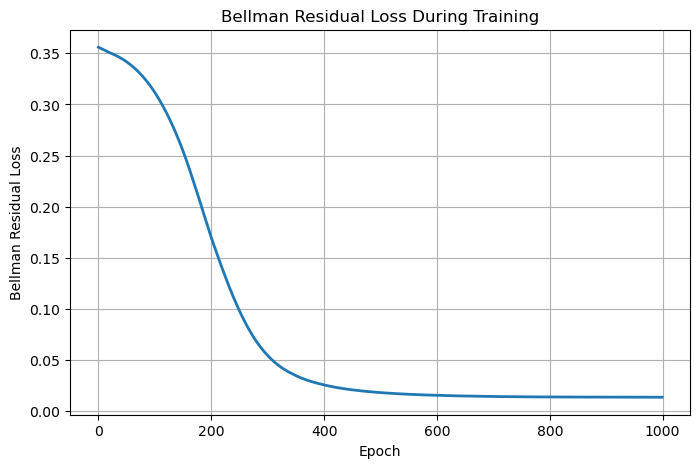

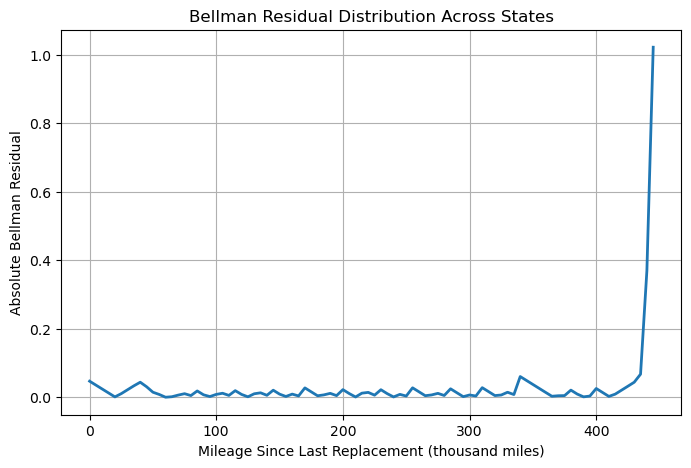

In [15]:
# Pure Bellman EV Recovery: No benchmark EV/Q labels, no anchors
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time

# 1. Prepare model inputs and Rust structural components

torch.manual_seed(123)
np.random.seed(123)

# Input: mileage state
x = np.asarray(states, dtype=np.float32).reshape(-1, 1)

# Normalize input state only for neural network stability
x_min = x.min()
x_max = x.max()
x_norm = (x - x_min) / (x_max - x_min)
X = torch.tensor(x_norm, dtype=torch.float32)

# Rust model components
P_keep_t = torch.tensor(P_keep, dtype=torch.float32)
P_replace_t = torch.tensor(P_replace, dtype=torch.float32)
keep_cost_t = torch.tensor(keep_cost, dtype=torch.float32)
replace_cost_t = torch.tensor(replace_cost, dtype=torch.float32)


# 2. Define EV network

class BellmanEVNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x).squeeze()
model = BellmanEVNetwork()

# 3. Training setup

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 1000
loss_history = []
start_time = time.time()

# 4. Train network using only Bellman residual loss

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Neural expected value approximation
    EV_pred = model(X)

    # Construct action values from neural EV
    Q_keep_pred = -keep_cost_t + beta * (P_keep_t @ EV_pred)
    Q_replace_pred = -replace_cost_t + beta * (P_replace_t @ EV_pred)

    # Ex-ante value under Type-I Extreme Value shocks
    V_pred = torch.logsumexp(
        torch.stack([Q_keep_pred, Q_replace_pred], dim=1
        ),
        dim=1
    )

    # Rust EV Bellman operator
    T_EV = P_keep_t @ V_pred

    # Bellman fixed-point residual
    residual = EV_pred - T_EV

    # Pure Bellman residual loss
    loss = torch.mean(residual ** 2)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

end_time = time.time()
training_time = end_time - start_time

# 5. Evaluate Bellman residual after training

model.eval()

with torch.no_grad():

    # Recovered EV from the trained network
    EV_recovered_t = model(X)

    # Recovered action values implied by EV
    Q_keep_recovered_t = -keep_cost_t + beta * (P_keep_t @ EV_recovered_t)
    Q_replace_recovered_t = -replace_cost_t + beta * (P_replace_t @ EV_recovered_t)

    # Recovered ex-ante value
    V_recovered_t = torch.logsumexp(
        torch.stack([Q_keep_recovered_t, Q_replace_recovered_t], dim=1
        ),
        dim=1
    )

    # Bellman-implied EV
    T_EV_recovered_t = P_keep_t @ V_recovered_t

    # Final Bellman residual
    residual_t = EV_recovered_t - T_EV_recovered_t

# Convert outputs to NumPy for later sections
EV_recovered = EV_recovered_t.cpu().numpy()
Q_keep_recovered = Q_keep_recovered_t.cpu().numpy()
Q_replace_recovered = Q_replace_recovered_t.cpu().numpy()
bellman_residual = residual_t.cpu().numpy()

# 6. Residual magnitude table

final_bellman_loss = np.mean(bellman_residual ** 2)
mean_abs_residual = np.mean(np.abs(bellman_residual))
max_abs_residual = np.max(np.abs(bellman_residual))
residual_summary = pd.DataFrame({
    "Metric": [
        "Final Bellman Residual Loss",
        "Mean Absolute Residual",
        "Maximum Absolute Residual",
        "Training Time"
    ],
    "Value": [
        final_bellman_loss,
        mean_abs_residual,
        max_abs_residual,
        training_time
    ]
})

print("Bellman Residual Summary")
print(residual_summary.to_string(index=False))

# 7. Plot Bellman residual loss during training

plt.figure(figsize=(8, 5))
plt.plot(loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Bellman Residual Loss")
plt.title("Bellman Residual Loss During Training")
plt.grid(True)
plt.show()

# 8. Plot residual distribution across states

mileage = states * 5000 * 0.001

plt.figure(figsize=(8, 5))
plt.plot(mileage,  np.abs(bellman_residual), linewidth=2)
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Absolute Bellman Residual")
plt.title("Bellman Residual Distribution Across States")
plt.grid(True)
plt.show()

#### Results

**Bellman Residual Summary** reports the numerical magnitude of the Bellman residual after training. The final Bellman residual loss is approximately **0.0135**, indicating that the squared residual has been reduced to a low level. The mean absolute residual is **0.0298**, which suggests that, on average, the recovered expected value function differs only slightly from the value implied by the Bellman operator.

The maximum absolute residual is **1.0219**, which is noticeably larger than the mean residual. This indicates that the residual error is not perfectly uniform across all mileage states. However, because the mean residual remains very small, the large maximum value is likely driven by a small number of states rather than by a general failure of Bellman consistency. The reported training time is approximately **2.65 seconds**, showing that the pure Bellman-based learning procedure is computationally inexpensive in this setting.

Taken together, the residual summary shows that the network successfully reduces the Bellman residual to a low level, although a small number of states still display larger deviations.

**Bellman Residual Loss During Training** shows how the Bellman residual loss changes over the training process. At the beginning of training, the loss is relatively high because the neural network parameters are randomly initialized and the initial expected value approximation does not satisfy the Bellman fixed-point condition.

As training proceeds, the loss declines sharply during the early and middle epochs. This shows that gradient-based optimization is able to use the Bellman residual as an effective learning signal. After this initial decline, the loss gradually flattens and approaches a stable low level. The absence of visible oscillation or divergence indicates that the training process is stable.

This pattern suggests that the network does not merely reduce the loss temporarily. Instead, it converges toward a stable Bellman-consistent approximation.

**Bellman Residual Distribution Across States** shows how the absolute Bellman residual varies across mileage states. For most mileage states, the residual remains very close to zero. This indicates that the recovered expected value function satisfies the Bellman equation well over most of the state space.

The main exception appears near the terminal mileage state, where the residual increases sharply. This boundary effect is consistent with the structure of the finite state space. At the upper boundary, transition probabilities become mechanically concentrated because further mileage increases cannot move beyond the final state. As a result, the Bellman equation is harder for the neural network to approximate exactly at the boundary.

Therefore, the distribution of residuals shows two patterns at the same time: Bellman consistency is achieved across most of the state space, but the terminal state remains the main source of residual error.

#### Overall Assessment

The pure Bellman-based learning procedure successfully identifies a Bellman-consistent solution. The final residual loss and mean absolute residual are small, the loss decreases smoothly during training, and residuals remain close to zero across most mileage states. Although a larger residual appears near the boundary state, this does not change the overall conclusion that the recovered expected value function approximately satisfies the Bellman fixed-point equation.


### 5.5.2 Numerical Recovery: Action-Value Recovery

Although the network is trained without benchmark action-value targets, the recovered expected value function can still be used to construct the implied action-value functions. This section compares the recovered action values with the benchmark solution in order to evaluate whether Bellman-consistent learning is sufficient to recover the benchmark numerical values.

#### Evaluation Strategy

Although benchmark action values are not used during training, they provide a useful reference for evaluating the numerical accuracy of the recovered solution after training has been completed.

The evaluation therefore consists of two parts.

First, the benchmark and recovered action-value functions are compared visually to determine whether the overall functional shapes are similar.

Second, numerical approximation errors are quantified using the mean squared error (MSE) and the normalized root mean squared error (NRMSE). These statistics provide an overall measure of how closely the recovered action-value functions approximate the benchmark solution.

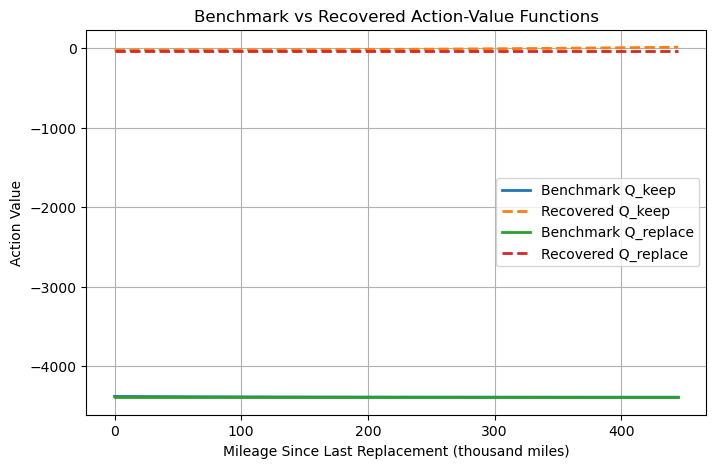

Action-Value Recovery Summary
 Metric        Value
  MSE_Q 1.908516e+07
NRMSE_Q 4.336135e+02


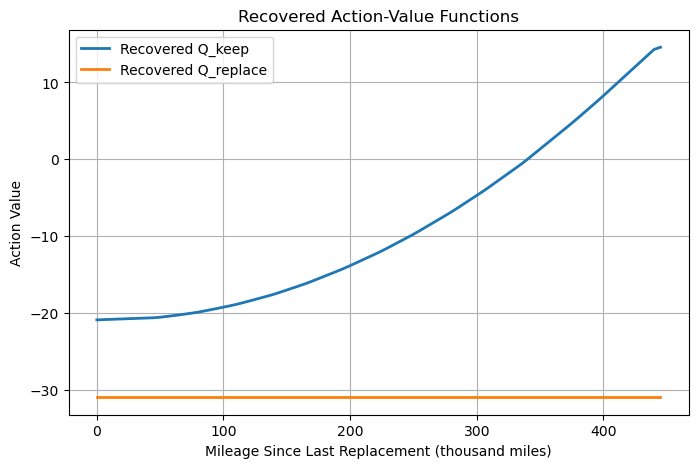

In [16]:
# Compare recovered Q with benchmark Q after pure Bellman learning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Visual comparison of action values

mileage = states * 5000 * 0.001

plt.figure(figsize=(8, 5))
plt.plot(mileage, Q_keep, linewidth=2, label="Benchmark Q_keep")
plt.plot(mileage, Q_keep_recovered, "--", linewidth=2, label="Recovered Q_keep")
plt.plot(mileage, Q_replace, linewidth=2, label="Benchmark Q_replace")
plt.plot(mileage, Q_replace_recovered, "--", linewidth=2, label="Recovered Q_replace")
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Action Value")
plt.title("Benchmark vs Recovered Action-Value Functions")
plt.legend()
plt.grid(True)
plt.show()

# 2. Compute approximation error

mse_q = np.mean(
    (
        (Q_keep - Q_keep_recovered) ** 2
        +
        (Q_replace - Q_replace_recovered) ** 2
    )
    / 2
)

benchmark_range = (
    max(Q_keep.max(), Q_replace.max())
    -
    min(Q_keep.min(), Q_replace.min())
)

nrmse_q = np.sqrt(mse_q) / benchmark_range

q_recovery_summary = pd.DataFrame({
    "Metric": [
        "MSE_Q",
        "NRMSE_Q"
    ],
    "Value": [
        mse_q,
        nrmse_q
    ]
})
print("Action-Value Recovery Summary")
print(q_recovery_summary.to_string(index=False))

# 3. Plot recovered action values only

plt.figure(figsize=(8, 5))
plt.plot(mileage, Q_keep_recovered, linewidth=2, label="Recovered Q_keep")
plt.plot(mileage, Q_replace_recovered, linewidth=2, label="Recovered Q_replace")
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Action Value")
plt.title("Recovered Action-Value Functions")
plt.legend()
plt.grid(True)
plt.show()

#### Results

**Benchmark vs Recovered Action Values** compares the benchmark action-value functions with the action values constructed from the recovered expected value function. The comparison shows a clear numerical separation between the two sets of action values.

The benchmark action values are located around a much lower numerical level, while the recovered action values are located much closer to zero. This indicates that the pure Bellman-based method does not recover the absolute scale of the benchmark action-value functions. The recovered keep value also displays a different slope from the benchmark keep value, especially at higher mileage states, where it increases rather than closely following the benchmark pattern.

This visual comparison therefore shows that satisfying the Bellman residual condition does not imply accurate recovery of benchmark action-value levels. The recovered action values are internally smooth, but they do not match the benchmark numerical solution.

**Action-Value Recovery Summary** confirms the visual evidence numerically. The mean squared error is approximately **1.91 × 10⁷**, which indicates a very large average squared difference between the recovered and benchmark action values. The normalized root mean squared error is approximately **433.61**, which remains extremely large even after adjusting for the scale of the benchmark action-value functions.

These error measures show that the discrepancy is not a minor numerical deviation. Instead, the recovered action-value functions differ substantially from the benchmark solution. Therefore, the pure Bellman residual training procedure does not successfully recover the benchmark action-value functions in absolute numerical terms.

**Recovered Action-Value Functions** displays the action values implied by the recovered expected value function alone. The recovered replacement value is nearly flat across mileage states, while the recovered keep value changes more strongly with mileage. The two recovered action-value functions remain smooth and do not exhibit unstable fluctuations.

This smoothness indicates that the neural network has learned a coherent internal representation rather than producing random or irregular predictions. However, smoothness alone is not sufficient for numerical recovery. The recovered functions remain far from the benchmark action values, especially in terms of absolute level.

#### Overall Assessment

The pure Bellman-based learning procedure does **not** recover the benchmark numerical action-value functions. Although the recovered action values are smooth and internally consistent, they differ substantially from the benchmark action-value functions in both level and shape. This result shows that Bellman consistency alone is not sufficient to uniquely recover the benchmark action-value solution.

### 5.5.3 Behavioral Recovery: Decision-Rule Recovery

Numerical recovery and behavioral recovery are not equivalent. Even if the recovered action-value functions differ numerically from the benchmark, they may still imply the same decision rule because decisions depend on the relative ranking of action values rather than their absolute magnitudes. This section therefore evaluates whether the recovered action-value functions generate the same decision rule as the Rust benchmark. 

#### Evaluation Strategy

Recovering action values accurately is not the only criterion for evaluating Bellman-based learning. From an economic perspective, the more important question is whether the recovered action values generate the same replacement decisions as the benchmark model.

Three complementary comparisons are therefore conducted.

First, the implied decision boundaries are compared by examining the difference between the keep and replacement action values.

Second, state-by-state decision consistency is evaluated by comparing the optimal action selected at each mileage state.

Finally, the overall replacement behavior implied by the recovered decision rule is compared with that of the benchmark model over the entire state space.

Together, these analyses evaluate whether Bellman-based learning successfully recovers the decision rule implied by the Rust model.

Decision Rule Recovery Summary
                      Metric  Value
           Decision Accuracy    1.0
   Number of Matching States   90.0
      Number of Total States   90.0
Number of Mismatching States    0.0

Decision Boundary Summary
                         Metric  Value
Benchmark Replacement Threshold    NaN
Recovered Replacement Threshold    NaN


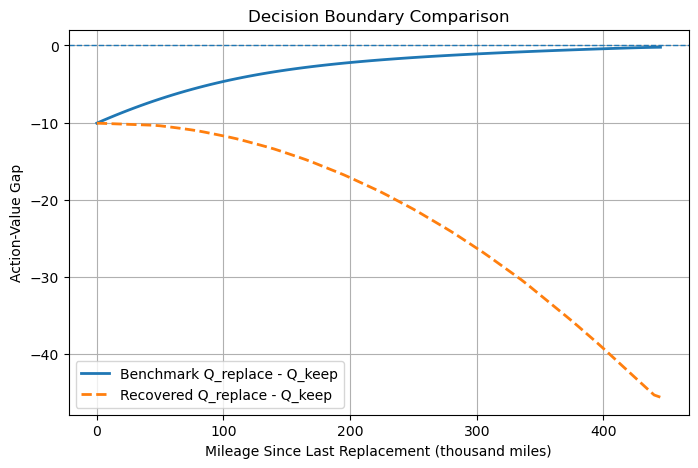

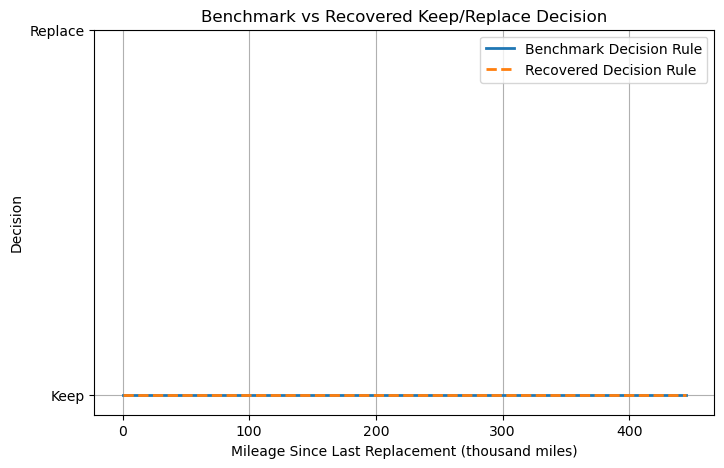

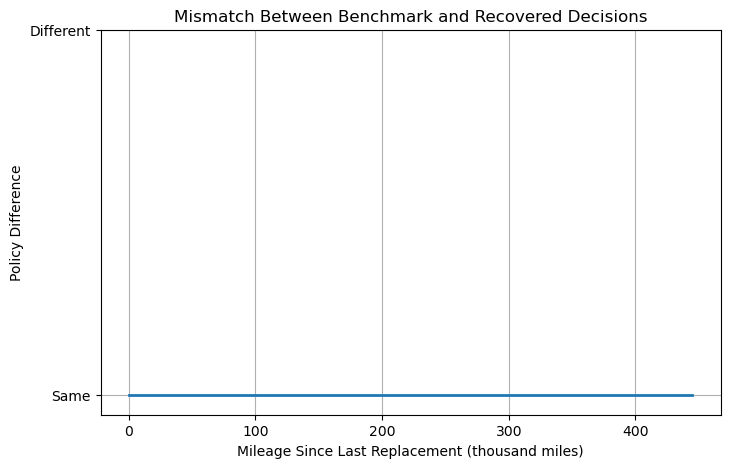

In [17]:
# Evaluate whether recovered Q implies the same decisions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Construct benchmark and recovered policies

Q_benchmark = np.column_stack([Q_keep, Q_replace])
Q_recovered = np.column_stack([Q_keep_recovered, Q_replace_recovered])

benchmark_policy = np.argmax(Q_benchmark, axis=1)
recovered_policy = np.argmax(Q_recovered, axis=1)

# 2. State-by-state decision consistency

decision_match = (benchmark_policy == recovered_policy)

decision_accuracy = np.mean(decision_match)

decision_summary = pd.DataFrame({
    "Metric": [
        "Decision Accuracy",
        "Number of Matching States",
        "Number of Total States",
        "Number of Mismatching States"
    ],
    "Value": [
        decision_accuracy,
        decision_match.sum(),
        len(states),
        len(states) - decision_match.sum()
    ]
})
print("Decision Rule Recovery Summary")
print(decision_summary.to_string(index=False))

# 3. Decision boundary comparison

benchmark_gap = Q_replace - Q_keep
recovered_gap = Q_replace_recovered - Q_keep_recovered

# Replacement region begins where replace value exceeds keep value.
benchmark_replace_states = states[benchmark_policy == 1]
recovered_replace_states = states[recovered_policy == 1]

if len(benchmark_replace_states) > 0:
    benchmark_threshold = benchmark_replace_states[0]
else:
    benchmark_threshold = np.nan

if len(recovered_replace_states) > 0:
    recovered_threshold = recovered_replace_states[0]
else:
    recovered_threshold = np.nan

threshold_summary = pd.DataFrame({
    "Metric": [
        "Benchmark Replacement Threshold",
        "Recovered Replacement Threshold"
    ],
    "Value": [
        benchmark_threshold,
        recovered_threshold
    ]
})
print("\nDecision Boundary Summary")
print(threshold_summary.to_string(index=False))

# 4. Plot action-value gaps: positive gap means replacement is preferred

plt.figure(figsize=(8, 5))
plt.plot(mileage, benchmark_gap, linewidth=2, label="Benchmark Q_replace - Q_keep")
plt.plot(mileage, recovered_gap, "--", linewidth=2, label="Recovered Q_replace - Q_keep")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Action-Value Gap")
plt.title("Decision Boundary Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 5. Plot state-by-state policy comparison

plt.figure(figsize=(8, 5))
plt.plot(mileage, benchmark_policy, linewidth=2, label="Benchmark Decision Rule")
plt.plot(mileage, recovered_policy, "--", linewidth=2, label="Recovered Decision Rule")
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Decision")
plt.yticks([0, 1], ["Keep", "Replace"])
plt.title("Benchmark vs Recovered Keep/Replace Decision")
plt.legend()
plt.grid(True)
plt.show()

# 6. Plot policy differences

policy_difference = (benchmark_policy != recovered_policy).astype(int)
plt.figure(figsize=(8, 5))
plt.plot(mileage, policy_difference, linewidth=2)
plt.xlabel("Mileage Since Last Replacement (thousand miles)")
plt.ylabel("Policy Difference")
plt.yticks([0, 1], ["Same", "Different"])
plt.title("Mismatch Between Benchmark and Recovered Decisions")
plt.grid(True)
plt.show()

#### Results

**Decision Rule Recovery Summary** reports the agreement between the benchmark decision rule and the decision rule implied by the recovered action values. The decision accuracy is **100%**, meaning that the recovered decision rule selects the same action as the Rust benchmark at every mileage state. All **90** states match, and there are **0** mismatching states.

This result is important because it shows that numerical recovery and decision recovery are not the same. Even though the recovered action values differ substantially from the benchmark action values, their ranking still generates the same optimal decision at every state.

**Decision Boundary Comparison** examines the difference between the replacement value and the keep value. The horizontal zero line represents the point at which the decision would switch from keeping to replacing. If the action-value gap crosses zero, a replacement threshold would exist.

In both the benchmark and recovered solutions, the action-value gap remains below zero across the observed state space. This means that the keep value remains higher than the replacement value for every mileage state. Therefore, replacement is never selected within the 90-state benchmark grid.

Because neither the benchmark nor the recovered policy crosses the zero line, no replacement threshold exists in either case. This is why the threshold summary reports missing values rather than numerical thresholds. The absence of a threshold is not a coding error; it reflects the fact that both policies recommend keeping the engine throughout the observed state space.

**Benchmark vs Recovered Keep/Replace Decision** directly compares the actions selected by the benchmark and recovered decision rules. The two policy lines overlap completely at the keep decision across all mileage states. This confirms that both decision rules produce the same replacement behavior over the full state space.

The figure also clarifies why the large action-value errors do not translate into decision errors. The recovered action values are numerically inaccurate, but the keep value remains above the replacement value at every state. Since the decision rule depends on the ranking of action values rather than their absolute magnitudes, the final decision remains correct.

**Mismatch Between Benchmark and Recovered Decisions** provides a direct check of whether the two policies disagree at any state. The policy difference remains at zero for all mileage states, meaning that there is no state at which the recovered decision rule chooses a different action from the benchmark policy.

This state-by-state result confirms the summary accuracy measure. The recovered decision rule does not merely match the benchmark decision rule on average; it matches it at every individual mileage state.

#### Overall Assessment

The recovered action-value functions fail to reproduce the benchmark numerical values, but they successfully preserve the action ranking required for decision making. Because the keep value remains above the replacement value throughout the state space, the recovered decision rule generates exactly the same decisions as the Rust benchmark. Therefore, pure Bellman-based learning does not recover the benchmark action-value functions numerically, but it successfully recovers the benchmark decision rule.

## 5.6 Training Performance

This section evaluates the training process of Bellman-based learning, with particular attention to computational efficiency and convergence behavior. 

### 5.6.1 Computational Efficiency

This subsection evaluates the computational efficiency of the proposed learning procedure by examining the resources required to obtain the recovered solution.

#### Method for Empirical Evaluation

Computational efficiency is evaluated from the perspective of the overall training cost required by the Bellman-based learning procedure. Three complementary indicators are reported.

The first indicator is the **training time**, which records the total wall-clock time required to complete the optimization process. This measure reflects the computational cost of the proposed learning framework under the benchmark experimental setting.

The second indicator is the **total number of training epochs**, which represents the complete optimization horizon adopted during training.

The third indicator is the **convergence epoch**, defined as the first training epoch at which the Bellman residual loss falls below a pre-specified convergence threshold. In this study, the threshold is set to **0.02**. This criterion is introduced solely for evaluation purposes and does not influence the optimization procedure itself.

Together, these indicators evaluate whether Bellman-based learning can recover a Bellman-consistent solution within a reasonable computational budget.

In [18]:
# Summarize computational cost of Bellman learning
import numpy as np
import pandas as pd

# Identify convergence epoch
tolerance = 0.02
convergence_epoch = None

for i, loss in enumerate(loss_history):

    if loss < tolerance:
        convergence_epoch = i + 1
        break

if convergence_epoch is None:
    convergence_epoch = epochs


# Training cost summary
training_summary = pd.DataFrame({
    "Metric": [
        "Training Time (seconds)",
        "Training Epochs",
        "Convergence Epoch"
    ],

    "Value": [
        training_time,
        epochs,
        convergence_epoch
    ]
})
print("Training Cost Summary")
print(training_summary.to_string(index=False))

Training Cost Summary
                 Metric      Value
Training Time (seconds)    2.50018
        Training Epochs 1000.00000
      Convergence Epoch  462.00000


#### Results

**Training Cost Summary** reports three indicators of the computational efficiency of Bellman-based learning: the total training time, the total number of training epochs, and the convergence epoch.

The total training time is approximately **2.54 seconds**, indicating that the Bellman-based learning procedure can be completed within a very short computational time under the Rust benchmark setting. This suggests that recovering a Bellman-consistent solution does not require substantial computational resources.

The optimization is performed over **1000 training epochs**, which defines the maximum training horizon used in the experiment. However, the convergence epoch is **462**, meaning that the Bellman residual loss first falls below the convergence threshold well before the end of training. Therefore, the network reaches a stable low-residual solution using less than half of the available optimization iterations.

The remaining training epochs mainly serve to make small refinements around an already stable solution rather than producing substantial improvements in Bellman consistency. This indicates that the computational cost of Bellman-based learning remains low despite the relatively long training horizon.

#### Overall Assessment

The computational results indicate that Bellman-based learning is computationally efficient. The proposed learning framework requires only a short training time and reaches convergence substantially earlier than the maximum training horizon. These findings suggest that Bellman-based learning can recover a Bellman-consistent solution within a reasonable computational budget.

### 5.6.2 Convergence Behavior

Computational efficiency alone does not guarantee successful learning. This subsection therefore examines whether the Bellman-based learning process converges in a stable and reliable manner during optimization.

#### Method for Empirical Evaluation

The convergence behavior of Bellman-based learning is evaluated by monitoring the evolution of the Bellman residual loss throughout the optimization process. Rather than focusing only on the final residual value, the entire training trajectory is examined. Specifically, the analysis considers four aspects of the optimization process.

First, the overall direction of the learning curve is examined to determine whether the Bellman residual decreases consistently during training.

Second, the convergence speed is evaluated by observing how rapidly the residual approaches a stable low-loss region.

Third, the stability of optimization is assessed by checking whether the learning curve exhibits large oscillations or abrupt fluctuations that would indicate unstable parameter updates.

Finally, the late-stage behavior of the learning curve is examined to determine whether the optimization converges toward a stable solution rather than diverging or continuing to fluctuate.

Taken together, these observations provide a comprehensive evaluation of the optimization dynamics of Bellman-based learning.

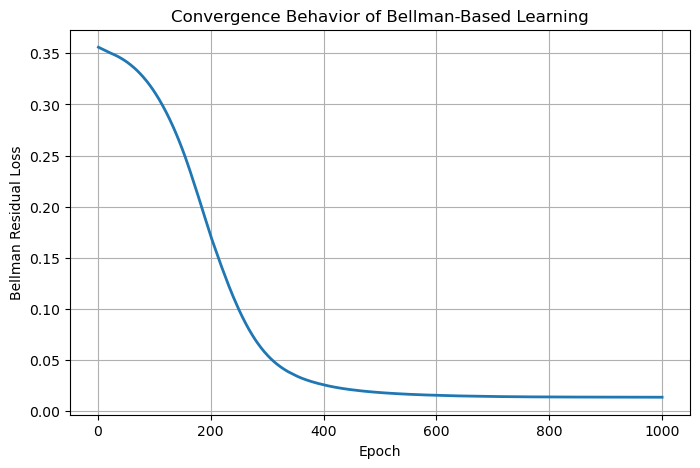

In [19]:
# Plot Bellman learning convergence
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, epochs + 1), loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Bellman Residual Loss")
plt.title("Convergence Behavior of Bellman-Based Learning")
plt.grid(True)
plt.show()

#### Results

**Convergence Behavior of Bellman-Based Learning** illustrates the complete optimization trajectory of the Bellman residual loss.

From the beginning of training, the Bellman residual loss decreases continuously without any sustained increase, indicating that the optimization proceeds in the correct direction throughout the learning process.

The convergence speed is not uniform over time. During the initial training stage, the loss decreases gradually while the neural network adjusts from random parameter initialization. The decline then becomes substantially steeper before approximately epoch **300**, indicating that the optimizer has identified parameter updates that rapidly improve Bellman consistency.

After the rapid decline, the learning curve enters a slower convergence stage. Around the convergence epoch, the Bellman residual loss falls below the predefined threshold of **0.02**. Beyond this point, the loss decreases only marginally and eventually approaches a stable low level, suggesting that the optimization has nearly converged.

Throughout the entire training process, the learning curve remains smooth and does not exhibit noticeable oscillations, abrupt jumps, or divergence. The optimization trajectory therefore demonstrates stable numerical behavior under the Bellman residual objective.

#### Overall Assessment

The convergence analysis shows that Bellman-based learning converges smoothly and reliably. The Bellman residual decreases continuously, reaches the convergence threshold within a reasonable number of epochs, and remains stable thereafter without signs of instability. These results indicate that the Bellman residual provides a stable optimization objective for learning the Bellman-consistent solution.

## 5.7 Robustness Assessment

This section examines whether the main conclusions of Chapter 5 remain robust under alternative experimental settings. Specifically, robustness is evaluated with respect to random initialization and neural network architecture.

### 5.7.1 Alternative Random Initialization

This subsection examines whether the recovery results depend on random parameter initialization during neural network training.

#### Method for Empirical Evaluation

Neural networks are initialized randomly before training. Different random initializations may lead to different parameter trajectories during optimization, even when the model structure, training data, and hyperparameters are unchanged. Therefore, robustness to random initialization is evaluated by repeating the pure Bellman-based learning experiment under several alternative random seeds.

The evaluation uses five seed configurations: **123**, **456**, **789**, **2025**, and **9999**. For each seed, the same Bellman-based training procedure is applied. The network is trained without benchmark expected value targets or benchmark action-value targets, and the loss function is constructed only from the Bellman residual.

For each seed, three recovery measures are reported. The first measure is the final Bellman residual, which evaluates whether the learned solution satisfies the Bellman fixed-point condition. The second measure is $MSE_Q$, which evaluates whether the recovered action-value functions match the Rust benchmark action values after training. The third measure is decision accuracy, which evaluates whether the recovered action values imply the same state-by-state decisions as the Rust benchmark.

This design assesses whether the main conclusions are sensitive to random initialization or remain qualitatively stable across different training starts.

In [20]:
# Robustness with respect to random initialization
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Random seeds to evaluate
seed_list = [123, 456, 789, 2025, 9999]
results = []

# Evaluate each random initialization
for seed in seed_list:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = BellmanEVNetwork()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    for epoch in range(epochs):
        optimizer.zero_grad()
        EV_pred = model(X)
        Q_keep_pred = (-keep_cost_t + beta * (P_keep_t @ EV_pred))
        Q_replace_pred = (-replace_cost_t + beta * (P_replace_t @ EV_pred))
        V_pred = torch.logsumexp(
            torch.stack([Q_keep_pred, Q_replace_pred],dim=1
            ),
            dim=1
        )
        T_EV = P_keep_t @ V_pred
        residual = EV_pred - T_EV

        loss = torch.mean( residual ** 2)
        loss.backward()

        optimizer.step()

    # Evaluation
    with torch.no_grad():

        EV_pred = model(X)

        Q_keep_pred = (-keep_cost + beta * (P_keep @ EV_pred.numpy()))
        Q_replace_pred = (-replace_cost + beta * (P_replace @ EV_pred.numpy()))

    mse_q = np.mean(
        (
            (Q_keep - Q_keep_pred) ** 2
            +
            (Q_replace - Q_replace_pred) ** 2
        ) / 2
    )

    benchmark_policy = np.argmax(
        np.column_stack(
            [Q_keep, Q_replace]
        ),
        axis=1
    )

    recovered_policy = np.argmax(
        np.column_stack(
            [Q_keep_pred, Q_replace_pred]
        ),
        axis=1
    )

    decision_accuracy = np.mean(
        benchmark_policy
        ==
        recovered_policy
    )

    results.append({
        "Seed": seed,

        "Bellman Residual":
        loss.item(),

        "MSE_Q":
        mse_q,

        "Decision Accuracy":
        decision_accuracy
    })
results = pd.DataFrame(results)
print("Recovery Results Across Seeds")
print(results)

Recovery Results Across Seeds
   Seed  Bellman Residual         MSE_Q  Decision Accuracy
0   123          0.013514  1.908516e+07                1.0
1   456          0.013341  1.922344e+07                1.0
2   789          0.013339  1.923077e+07                1.0
3  2025          0.013665  1.916354e+07                1.0
4  9999          0.013289  1.923579e+07                1.0


#### Results

**Recovery Results Across Seeds** reports the Bellman residual, action-value recovery error, and decision accuracy for each random initialization.

Across all five seeds, the final Bellman residual remains very small. The residual values range from approximately **0.0133** to **0.0137**. This narrow range indicates that the Bellman-based learning procedure consistently converges to a Bellman-consistent solution regardless of the initial network parameters.

The action-value recovery error remains large for every random seed. The $MSE_Q$ values are all around **1.91 × 10⁷** to **1.92 × 10⁷**. This shows that the failure to recover the benchmark numerical action-value functions is not caused by an unlucky initialization. Instead, the large action-value error appears consistently across alternative random starts.

Decision accuracy is **1.0** for every seed. This means that, although the recovered action values differ numerically from the benchmark action values, the implied decisions are identical to the benchmark decisions across all mileage states for every random initialization.

The pattern is therefore highly stable across seeds. Random initialization changes the exact numerical path of training, but it does not change the qualitative conclusion: Bellman consistency is achieved, benchmark action values are not numerically recovered, and the decision rule is fully recovered.

#### Overall Assessment

The robustness results show that the main findings are not driven by random initialization. Across all seed configurations, the model consistently produces small Bellman residuals, large numerical action-value errors, and perfect decision-rule recovery. This indicates that the qualitative conclusion of Chapter 5 is stable across random training starts.

### 5.7.2 Alternative Network Specifications

This subsection evaluates whether the main conclusions are sensitive to the choice of neural network architecture.

#### Method for Empirical Evaluation

The baseline Bellman-based learning experiment uses a fully connected neural network with two hidden layers and 32 hidden units per layer. Although this architecture is intentionally simple, it is still necessary to examine whether the main results depend on this specific network specification.

Robustness to network architecture is evaluated by comparing three alternative specifications. The **Small** network uses one hidden layer with 16 hidden units. The **Baseline** network uses two hidden layers with 32 hidden units per layer. The **Medium** network uses two hidden layers with 64 hidden units per layer.

For each architecture, the same pure Bellman-based learning procedure is applied. The network is trained without benchmark expected value targets or benchmark action-value targets. The Bellman residual remains the only training signal. After training, each architecture is evaluated using the same three measures: final Bellman residual, $MSE_Q$, and decision accuracy.

This design assesses whether the main conclusions depend on network capacity or remain qualitatively stable when the neural network size changes.

In [21]:
# Robustness with respect to network architecture
architectures = {
    "Small":
    [16],

    "Baseline":
    [32,32],

    "Medium":
    [64,64]
}
results = []

for name, hidden in architectures.items():
    torch.manual_seed(123)
   
    class EVNetwork(nn.Module):
        def __init__(self):
            super().__init__()
            layers=[]
            input_dim=1

            for h in hidden:
                layers.append(
                    nn.Linear(
                        input_dim,
                        h
                    )
                )

                layers.append(
                    nn.ReLU()
                )

                input_dim=h

            layers.append(
                nn.Linear(
                    input_dim,
                    1
                )
            )

            self.network=nn.Sequential(
                *layers
            )

        def forward(self,x):
            return self.network(x).squeeze()

    model=EVNetwork()
    optimizer=optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        optimizer.zero_grad()
        EV_pred=model(X)
        Q_keep_pred=(-keep_cost_t + beta*(P_keep_t@EV_pred))
        Q_replace_pred=(-replace_cost_t + beta*(P_replace_t@EV_pred))
       
        V_pred=torch.logsumexp(
            torch.stack(
                [
                    Q_keep_pred,
                    Q_replace_pred
                ],
                dim=1
            ),
            dim=1
        )
        residual=EV_pred-(P_keep_t@V_pred)
        loss=torch.mean(residual**2)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        EV_pred=model(X)
        Q_keep_pred=(-keep_cost + beta*(P_keep@EV_pred.numpy()))
        Q_replace_pred=(-replace_cost + beta*(P_replace@EV_pred.numpy()))

    mse_q=np.mean(
        (
            (Q_keep-Q_keep_pred)**2
            +
            (Q_replace-Q_replace_pred)**2
        )/2
    )

    benchmark_policy=np.argmax(
        np.column_stack(
            [
                Q_keep,
                Q_replace
            ]
        ),
        axis=1
    )

    recovered_policy=np.argmax(
        np.column_stack(
            [
                Q_keep_pred,
                Q_replace_pred
            ]
        ),
        axis=1
    )

    decision_accuracy=np.mean(
        benchmark_policy
        ==
        recovered_policy
    )

    results.append({
        "Architecture":
        name,

        "Bellman Residual":
        loss.item(),

        "MSE_Q":
        mse_q,

        "Decision Accuracy":
        decision_accuracy
    })
results=pd.DataFrame(results)
print("Recovery Results Across Architectures")
print(results)

Recovery Results Across Architectures
  Architecture  Bellman Residual         MSE_Q  Decision Accuracy
0        Small          0.136142  1.914017e+07                1.0
1     Baseline          0.013514  1.908516e+07                1.0
2       Medium          0.012807  1.921260e+07                1.0


#### Results

**Recovery Results Across Architectures** reports the recovery outcomes for the Small, Baseline, and Medium network specifications.

The Small network produces a final Bellman residual of approximately **0.1361**, which is noticeably larger than the residual obtained under the Baseline and Medium specifications. This indicates that the smaller network has less capacity to satisfy the Bellman fixed-point condition precisely. Since it contains only one hidden layer with 16 units, its representational flexibility is more limited.

The Baseline network reduces the Bellman residual to approximately **0.0135**, while the Medium network produces a similar residual of approximately **0.0128**. The improvement from Baseline to Medium is very small. This suggests that increasing the hidden units from 32 to 64 does not substantially improve Bellman consistency in this one-dimensional Rust benchmark setting.

The action-value recovery error remains large across all architectures. The $MSE_Q$ values stay around **1.91 × 10⁷** to **1.92 × 10⁷** for all three networks. This indicates that increasing network capacity does not resolve the numerical action-value recovery problem. The failure to recover benchmark action-value levels therefore cannot be attributed simply to insufficient network size.

Decision accuracy remains **1.0** for all three architectures. Even the Small network, despite having a larger Bellman residual, still generates the same state-by-state decisions as the Rust benchmark. This confirms that decision-rule recovery is robust to changes in network architecture.

Overall, the architecture comparison shows that larger networks improve Bellman residual performance relative to the Small network, but they do not change the central qualitative result. Across all specifications, Bellman-based learning does not recover benchmark action values numerically, but it does recover the benchmark decision rule.

#### Overall Assessment

The robustness results indicate that the main conclusions are not driven by the baseline network specification. Smaller networks produce larger Bellman residuals, while larger networks slightly improve Bellman consistency. However, all architectures produce large numerical action-value errors and perfect decision-rule recovery. This suggests that the central finding is robust to reasonable changes in network architecture: Bellman consistency alone does not guarantee numerical action-value recovery, but it is sufficient in this experiment to recover the benchmark replacement decisions.

## 5.8 Interpretation of the Recovered Action-Value Function

The previous sections evaluate structural recovery, numerical recovery, and behavioral recovery under the Bellman-based learning framework. Based on these findings, this section discusses their implications for Bellman-based learning in the Rust model. 

### 5.8.1 Overall Assessment of Recovery

This subsection provides an overall assessment of the recovery results and summarizes the principal findings of Chapter 5.

**The Central Research Question**

This chapter investigates whether the action-value function defined by the Rust model can be recovered directly from the Bellman equation without relying on benchmark action-value targets.

Unlike the supervised learning framework developed in Chapter 4, the Bellman-based learning framework receives no benchmark expected value functions and no benchmark action-value functions during training. Instead, the neural network learns solely by minimizing the Bellman residual implied by the structural components of the Rust model.

The central research question of this chapter can be summarized as $$\text{Can the Rust action-value function be recovered directly from the Bellman structure?}$$

**Three Dimensions of Recovery**

The empirical evidence indicates that recovery should not be viewed as a single concept. Instead, Bellman-based learning produces three distinct dimensions of recovery.

Structural recovery concerns whether the recovered solution satisfies the Bellman structure of the Rust model. Numerical recovery concerns whether the recovered action-value functions reproduce the benchmark numerical solution. Behavioral recovery concerns whether the recovered solution generates the benchmark decision rule.

These three dimensions represent progressively stronger notions of successful recovery. Structural recovery does not necessarily imply numerical recovery, while numerical differences do not necessarily alter the resulting optimal decisions. Consequently, Bellman-based learning should be evaluated from structural, numerical, and behavioral perspectives rather than by numerical approximation alone.

**Summary of the Empirical Findings**

The findings reveal a clear pattern across these three dimensions of recovery.

First, structural recovery is successfully achieved. The Bellman residual converges to a very small value throughout the state space, indicating that the recovered expected value function satisfies the Bellman fixed-point equation with a high degree of accuracy. The neural network successfully recovers a structurally consistent solution. 

Second, numerical recovery is not achieved. The recovered action-value functions differ substantially from the benchmark numerical solution. Both the numerical errors and the graphical evidence show that Bellman consistency alone does not reproduce the benchmark action-value functions. 

Third, behavioral recovery is successfully achieved. Despite these numerical differences, the recovered policy generates exactly the same replacement decisions as the benchmark model. The recovered solution therefore preserves the optimal decision rule implied by the Rust model.

Taken together, the empirical evidence may be summarized as $$\text{Structural Recovery}\;\checkmark\Longrightarrow\text{Numerical Recovery}\;\times\Longrightarrow\text{Behavioral Recovery}\;\checkmark$$

This pattern constitutes the central empirical finding of Chapter 5.

**Implications for Bellman-Based Learning**

These findings suggest that Bellman-based learning should not be evaluated solely according to its ability to reproduce benchmark numerical action-value functions.

Instead, the experimental evidence suggests that Bellman-based learning is capable of recovering a Bellman-consistent solution together with its implied optimal decision behavior, even when the recovered numerical action values differ from the benchmark solution.

The principal contribution of Chapter 5 is therefore not to demonstrate exact numerical recovery of the benchmark action-value functions. Rather, it shows that economically meaningful decision behavior can be recovered directly from the Bellman structure of the Rust model without relying on externally generated benchmark action-value targets.

**Transition to the Following Discussion**

The three dimensions of recovery identified above motivate the discussions that follow.

The following subsections examine these issues in greater detail. Section 5.8.2 explains why Bellman consistency does not necessarily imply recovery of the benchmark numerical action-value functions. Section 5.8.3 then discusses why accurate decision behavior can nevertheless be recovered despite substantial numerical differences in the recovered action-value functions. Finally, Section 5.8.4 considers the broader economic implications of these findings for structural dynamic decision models.

### 5.8.2 Bellman Consistency and Solution Recovery

This subsection explains why successful structural recovery, as measured by Bellman consistency, does not guarantee recovery of the benchmark numerical action-value functions. The discussion clarifies the relationship between satisfying the Bellman equation and recovering the numerical solution obtained from the benchmark dynamic programming algorithm.

**Bellman Consistency as a Structural Requirement**

The Bellman equation provides the structural condition that any valid solution of the Rust model must satisfy. Throughout Chapter 5, the neural approximation is trained solely by minimizing the Bellman residual, $$R(x;\theta)=EV_\theta(x)-T(EV_\theta)(x)$$, without using any benchmark expected values or benchmark action-value functions. Consequently, the learning process is driven entirely by structural consistency rather than numerical supervision.

The experimental results show that the Bellman residual converges to a very small value across almost the entire state space. This indicates that the recovered expected value function satisfies the Bellman fixed-point equation to a high degree of accuracy. From the perspective of the Bellman equation, the recovered solution is therefore structurally consistent with the Rust model. 

**Why Bellman Consistency Does Not Guarantee Numerical Recovery**

At first glance, it may seem that a Bellman-consistent solution should also recover the benchmark numerical action-value functions. However, the empirical results presented in this chapter demonstrate that this conclusion does not necessarily hold. 

Although the recovered solution satisfies the Bellman equation with only small residual errors, the recovered action-value functions differ substantially from the benchmark numerical solution. The approximation errors reported in Section 5.5.2 remain relatively large, and the visual comparison of the action-value functions reveals persistent numerical differences across the state space.

This distinction indicates that satisfying the Bellman equation and reproducing the benchmark numerical solution are fundamentally different objectives. The distinction between these objectives is explained in the following discussion. 

**Internal Consistency versus Benchmark Consistency**

The Bellman equation imposes an internal consistency condition among the expected value function, the action-value functions, and the transition structure of the model. During training, the neural approximation is required to satisfy $$EV_\theta=T(EV_\theta)$$, which ensures that the recovered solution is consistent with the Bellman operator generated by the Rust model.

However, the Bellman equation does not require the recovered solution to coincide with the benchmark numerical solution. In particular, it does not require $$EV_\theta=EV^{Benchmark}$$, or, equivalently, $$Q_\theta(x,a)=Q^{Benchmark}(x,a)$$

The benchmark solution is only one particular numerical solution obtained through the benchmark dynamic programming procedure. Since the Bellman residual contains no information about these benchmark numerical values, minimizing the Bellman residual alone cannot directly force the recovered solution to reproduce them.

Thus, the framework evaluates structural consistency rather than numerical equality.

**Necessary but Not Sufficient**

These results clarify the logical relationship between Bellman consistency and numerical recovery. Numerical recovery necessarily requires Bellman consistency. Any solution that violates the Bellman equation cannot represent a valid solution of the Rust model.

However, satisfying the Bellman equation alone does not guarantee numerical recovery. Bellman consistency is therefore a necessary condition for numerical recovery, but it is not a sufficient condition. This relationship may be summarized as $$\text{Numerical Recovery}\Longrightarrow\text{Bellman Consistency}$$, whereas$$\text{Bellman Consistency}\centernot\Longrightarrow\text{Numerical Recovery}$$

Therefore, Bellman consistency should be interpreted as evidence that the recovered solution satisfies the structural requirements of the dynamic programming model, rather than evidence that the benchmark numerical solution has been uniquely identified.

**Implications for Bellman-Based Learning**

The experimental results show that Bellman-based learning successfully achieves structural recovery even without benchmark supervision. Nevertheless, structural consistency alone is insufficient to uniquely determine the benchmark numerical action-value functions when no benchmark targets are provided during training.

This finding should not be interpreted as evidence that Bellman-based learning fails to recover economically meaningful information. Although the benchmark numerical action-value functions are not reproduced, the experimental results indicate that the recovered solution may still preserve the optimal decision behavior implied by the Rust model.

This distinction between numerical and behavioral recovery is examined in the following subsection.

### 5.8.3 From Action-Value Recovery to Decision Recovery

This subsection explains why successful recovery of decision behavior can still be achieved even when the benchmark numerical action-value functions are not recovered.

**Overall Finding**

A key finding of this chapter is that numerical recovery and behavioral recovery represent two fundamentally different dimensions of successful recovery. Although the recovered action-value functions differ substantially from the benchmark numerical solution, they nevertheless generate exactly the same replacement decisions across all mileage states.

At first glance, this result may appear surprising. If the numerical action values are not recovered accurately, it might be expected that the resulting decisions would also differ from those of the benchmark model. However, the experimental results demonstrate that this intuition does not necessarily hold in dynamic programming problems.

The reason is that optimal decisions are determined by the relative ordering of action values rather than by their absolute numerical levels.

**Decision Rules Depend on Relative Ordering**

In the Rust model, the optimal decision at each mileage state is determined by comparing the action values associated with the feasible actions. Formally, the decision rule is $$a^*(x)=\arg\max_a Q(x,a)$$

This expression shows that the optimal decision depends only on the relative ordering of the action values, not on their absolute numerical magnitudes. Only the action with the higher value determines the optimal decision.

Thus, two different action-value functions may imply exactly the same policy provided that they preserve the same ordering across actions. Even if $$Q_{\text{Recovered}}(x,a)\neq Q_{\text{Benchmark}}(x,a)$$, the resulting decisions remain identical whenever $$\arg\max_a Q_{\text{Recovered}}(x,a)=\arg\max_a Q_{\text{Benchmark}}(x,a)$$

Although the recovered action-value functions differ numerically from the benchmark solution, they preserve the relative ranking between the keep and replace actions throughout the entire state space. As a result, the recovered policy coincides exactly with the benchmark policy.

**Behavioral Recovery Is More Robust Than Numerical Recovery**

Recovering the exact numerical action-value functions requires reproducing the benchmark value associated with every state-action pair. This is a stronger requirement because even small numerical differences contribute to approximation error.

By contrast, recovering the optimal decision rule requires only that the correct action remain the preferred alternative. As long as the ordering between competing action values is preserved, the resulting decision is unchanged.

From this perspective, behavioral recovery represents a more robust objective than exact numerical recovery. Numerical values may vary across alternative structurally consistent solutions, while the implied optimal decisions can remain identical.

The results provide clear evidence of this distinction. Pure Bellman-based learning does not reproduce the benchmark numerical action-value functions, yet it successfully preserves the optimal replacement decisions implied by the Rust model.

**Behavioral Recovery as the Economically Relevant Objective**

The distinction is particularly important from the perspective of structural dynamic programming.

The primary objective of the Rust model is not to determine numerical values for their own sake. Rather, the objective is to characterize optimal replacement behavior under dynamic incentives.

Accordingly, the economically relevant outcome is whether the recovered solution generates the same optimal decisions as the benchmark model. If the recovered action-value functions preserve the correct behavioral implications, then the essential decision logic of the model has also been preserved.

The experimental results therefore suggest that successful behavioral recovery depends primarily on preserving the relative ordering of action values rather than reproducing their exact numerical levels.

**Transition to Economic Interpretation**

The distinction established above naturally leads to the economic interpretation of the recovered solution.

Although Bellman-based learning does not uniquely recover the benchmark numerical action-value functions, it nevertheless preserves the optimal replacement behavior implied by the Rust model. This indicates that the information recovered through Bellman-based learning extends beyond numerical approximation and retains economically meaningful decision structure.

The economic implications of this behavioral recovery are discussed in the following subsection.

### 5.8.4 Economic Implications

This subsection discusses the economic implications of the recovered action-value functions and the corresponding replacement decisions.

**The Economic Meaning of the Action-Value Function**

The action-value function is not merely a numerical mapping between mileage states and actions. Within the Rust model, it represents the total economic value associated with each feasible decision, combining both the immediate cost incurred today and the discounted value of future decisions.

For a general action, the action-value function is given by $$Q(x,a)=-C(x,a)+\beta\sum_{x'}P(x'|x,a)EV(x')$$

This expression illustrates that every action value consists of two economically meaningful components. The first component reflects the current economic consequence of the chosen action through the cost function. The second component represents the continuation value generated by future optimal decisions. Accordingly, the action-value function summarizes the dynamic trade-off between current costs and future benefits.

Successful behavioral recovery therefore indicates that the underlying economic decision structure has been recovered, rather than merely a collection of numerical values. 

**Preservation of the Keep-Replace Trade-Off**

The most fundamental economic mechanism in the Rust model is the trade-off between continuing to operate the current engine and replacing it with a new one.

Keeping the engine avoids the replacement cost but increases expected future maintenance costs as mileage accumulates. Replacing the engine requires paying a substantial immediate replacement cost while reducing future maintenance expenses through a renewed engine condition. The action-value functions summarize these competing incentives. 

Although the recovered action-value functions differ numerically from the benchmark solution, the experimental results show that their relative ordering remains unchanged throughout the state space. Consequently, the economic trade-off between keeping and replacing the engine is preserved.

This result indicates that Bellman-based learning successfully captures the underlying economic comparison between competing actions even when exact numerical recovery is not achieved.

**Preservation of Replacement Incentives**

The replacement decision reflects the economic incentives embedded in the dynamic optimization problem.

As mileage increases, the expected future maintenance cost associated with continued operation becomes progressively larger. At the same time, the economic attractiveness of replacement increases because installing a new engine reduces future operating costs.

These changing incentives are reflected in the relative ordering of the keep and replace action values rather than in their absolute numerical magnitudes. 

The results show that Bellman-based learning preserves these relative incentives. Although the recovered action-value functions differ numerically from the benchmark values, they continue to identify the same economically preferred action at every mileage state.

Therefore, the recovered solution preserves the incentive structure governing optimal replacement behavior.

**Preservation of the Dynamic Decision Structure**

The Rust model is fundamentally a dynamic decision problem rather than a static optimization problem.

Current decisions influence future states through the transition probabilities, while future states contribute to current decisions through the continuation value represented by the Bellman equation. Every optimal decision therefore reflects both immediate economic consequences and discounted future opportunities. 

The Bellman equation therefore links present and future decisions through the recursive relationship $$EV=T(EV)$$, where the Bellman operator summarizes the dynamic optimization process.

The empirical results show that the recovered expected value function satisfies this recursive structure with only small Bellman residuals. As a result, the recovered action-value functions continue to embody the same dynamic decision mechanism implied by the Rust model.

This result indicates that Bellman-based learning preserves the recursive economic logic of the dynamic programming problem even without exact numerical recovery. 

**Overall Economic Interpretation**

Overall, the empirical results indicate that Bellman-based learning preserves the economically meaningful components of the Rust model despite failing to recover the benchmark numerical action-value functions.

The recovered solution maintains the trade-off between keeping and replacing the engine, preserves the incentive structure governing replacement decisions, and reproduces the dynamic recursive relationships implied by the Bellman equation. These structural properties are sufficient to generate the same optimal replacement behavior observed in the benchmark model.

Consequently, the experimental evidence suggests that the primary contribution of Bellman-based learning is not exact numerical approximation but recovery of the economic decision structure underlying the dynamic programming problem.

Taken together, these findings suggest that learning directly from economic structure provides an alternative to benchmark-based numerical supervision for recovering economically meaningful decision objects.

Taken together, these findings suggest that Bellman-based learning represents one realization of the broader structure-guided learning framework and should be understood primarily as **a method for recovering the structural relationships and behavioral implications of a dynamic programming model**, rather than for reproducing a particular benchmark numerical representation of the action-value function.

# 6 Discussion and Conclusions

This chapter first discusses the methodological framework established throughout the study and then concludes by reflecting on its broader implications for computational economics. 

## 6.1 Discussion

This section discusses the broader methodological contribution of the study. Chapters 4 and 5 constitute two complementary components of a unified learning framework for dynamic discrete choice models. Together, they establish a structure-guided learning framework that combines target selection, neural approximation, and structural recovery within the Rust model.

**A Two-Stage Learning Framework**

Instead of applying neural networks directly to the Rust model, this study first considers a more fundamental question: **what should be learned?**

Chapter 4 addresses this problem by comparing three candidate learning objects—the expected value function, the action-value function, and the replacement probability function. Rather than assuming the appropriate learning target in advance, the comparison identifies the action-value function as the most suitable object for neural approximation.

Having identified the learning target, Chapter 5 addresses the next methodological question. Rather than providing benchmark action-value functions during training, the selected target is recovered directly from the Bellman structure of the Rust model. The emphasis therefore shifts from selecting an appropriate learning target to recovering that target through structural consistency.

Together, the two chapters form a unified learning framework: $$
\text{Target Selection}\Longrightarrow
\text{Neural Approximation}\Longrightarrow
\text{Structural Recovery}
$$

Within this framework, Chapter 4 determines **what should be learned**, while Chapter 5 investigates **how the selected object can be learned from economic structure itself**.

**From Data-Driven Learning to Structure-Guided Learning**

Although both chapters employ neural networks to recover the action-value function, they differ fundamentally in the information used for learning.

Chapter 4 follows a data-driven learning paradigm. Benchmark action-value functions generated by the classical dynamic programming solution provide explicit numerical supervision, and the neural network learns by approximating these externally supplied targets.

Chapter 5 instead adopts a structure-guided learning paradigm. Benchmark targets are removed entirely, and the Bellman equation becomes the learning signal. Rather than reproducing previously computed numerical solutions, the neural network learns by satisfying the structural relationships implied by the underlying dynamic optimization problem.

The distinction therefore lies not in the neural network itself, but in the source of learning information. One approach learns from benchmark numerical targets, whereas the other learns directly from economic structure.

This progression reflects a broader shift from data-driven approximation toward structure-guided learning. Within the proposed framework, Bellman-based learning represents one realization of this broader paradigm, in which economic structure itself provides the learning signal. 

**The Action-Value Function as the Interface Between Economics and Learning**

The action-value function occupies a unique position within the learning framework developed in this study.

In Chapter 4, it is identified as the most suitable learning target through comparative evaluation. In Chapter 5, the same object becomes the quantity recovered through Bellman-based learning. Consequently, the action-value function serves as the interface between neural approximation and the underlying economic model.

From an economic perspective, the action-value function summarizes the expected value associated with each feasible decision and determines the optimal replacement policy. From a computational perspective, it provides a continuous function that can be represented efficiently by neural networks.

The action-value function therefore serves as an interface between economics and machine learning. Rather than treating dynamic programming and neural approximation as competing methodologies, both approaches are connected through the common objective of recovering the same economically meaningful object. 

Across the study, the role of the action-value function gradually evolves—from the solution object of dynamic programming, to the selected learning target, and finally to the conceptual interface connecting economic theory with neural approximation.

**Toward a Structure-Guided Learning Framework**

Taken together, the results of Chapters 4 and 5 suggest a broader computational perspective for dynamic discrete choice models.

When benchmark solutions are available, neural networks can accurately approximate economically meaningful targets through supervised learning. When benchmark targets are unavailable or expensive to obtain, the Bellman equation itself can instead provide the learning signal, allowing neural networks to recover structurally consistent value functions and decision rules directly from the model.

Accordingly, the proposed framework extends beyond demonstrating the feasibility of neural approximation within the Rust model. More importantly, it establishes a coherent framework in which target selection, neural approximation, and structural recovery form successive stages of a unified computational methodology.

Rather than viewing neural networks solely as prediction tools, this framework illustrates how economic structure itself can guide the learning process. In this sense, neural approximation becomes not merely a numerical approximation technique, but a computational approach that remains closely connected to the theoretical foundations of dynamic programming.

This methodological perspective naturally leads to the broader issue of the position of neural approximation relative to classical dynamic programming.

## 6.2 Conclusion

This section concludes the study by reflecting on the trade-off between classical dynamic programming and neural approximation from the perspective of dynamic decision-making and computational economics. Rather than simply summarizing the empirical findings, it argues that the methodological choice examined in this study exhibits a mirror relationship with the replacement decision logic embodied in the Rust model. Both problems are governed by the same dynamic replacement logic. 

**A Mirror Logic of Dynamic Replacement**

The Rust model studies a dynamic replacement problem. Harold Zurcher repeatedly decides whether to continue operating the current bus engine or replace it with a new one. The decision is not determined by whether a newer engine exists, but by whether replacement generates higher expected long-run value than continued operation.

This study examines a different problem governed by the same decision logic. Instead of choosing between engines, the researcher evaluates computational methods. The question is whether to continue relying on the classical dynamic programming procedure or to adopt neural approximation for solving dynamic decision problems.

The objects of choice are different. In the Rust model, the object is a bus engine. In this study, the object is a computational approach. However, both decisions require comparing the value of keeping an existing option with the value of adopting a new alternative.

The mirror relationship therefore extends beyond a simple analogy. It means that both are governed by the same underlying decision logic: replacement should be considered only when the expected gains from the new alternative exceed the costs of abandoning the existing one.

**The Value of Preserving Classical Dynamic Programming**

The first implication of this mirror logic is that an existing method should not be discarded simply because a new alternative becomes available.

In the Rust model, an existing engine may still be worth keeping even when it is old. As long as the expected value of continued operation remains higher than the value of replacement, keeping the current engine is the optimal decision. The presence of a replacement option does not automatically make replacement desirable.

The same reasoning applies to classical dynamic programming. The availability of neural networks does not automatically reduce the value of the classical solution procedure. Dynamic programming continues to provide exact numerical solutions, transparent economic interpretation, theoretical guarantees, and a direct connection to the structural model.

Therefore, methodological innovation should not be interpreted as methodological elimination. The existence of neural approximation does not automatically invalidate classical dynamic programming.

**When Methodological Replacement Becomes Worthwhile**

The second implication is that replacement becomes attractive only when the conditions of the decision problem change.

In the Rust model, replacement becomes optimal when continued operation becomes sufficiently costly. As mileage accumulates, maintenance costs rise and the expected value of keeping the old engine declines. Replacement becomes attractive not because the old engine is old, but because keeping it has become costly relative to replacement.

A similar transition appears in computational economics. Classical dynamic programming is not limited because it is theoretically wrong. Its limitation appears when the computational burden becomes sufficiently large. Expanding state spaces, repeated Bellman iterations, and increasing numerical complexity raise the cost of exact solution.

Under these conditions, neural approximation becomes increasingly attractive. Its value does not come from replacing economic structure, but from providing a computational strategy that may reduce solution costs while preserving economically meaningful information.

Accordingly, the relevant question is not whether neural approximation is universally superior to dynamic programming. The relevant question is under what computational conditions methodological replacement becomes worthwhile.

**Methodological Replacement as a Dynamic Decision Problem**

Viewed from this perspective, the present study does more than compare to dynamic programming with neural approximation. Rather, it is to show that the replacement logic embodied in the Rust model also provides a useful framework for methodological choice in computational economics.

The Rust model asks:

> **When is engine replacement worthwhile?**

This study asks:

> **When is methodological replacement worthwhile?**

Both questions are dynamic replacement problems. Neither advocates replacement whenever a new alternative exists. Instead, both require comparing expected long-run gains with associated costs.

This logic can be summarized as $$
\text{Replace only if Expected Gains from Replacement} >
\text{Costs of Replacement}.
$$

In the Rust model, this comparison concerns the keep and replace values of a bus engine. In this study, it concerns the trade-off between the precision and transparency of classical dynamic programming and the scalability of neural approximation.

**Replacement as a Trade-Off Rather Than a Substitution**

The empirical findings of this study support this interpretation.

Chapter 4 shows that the action-value function is the most suitable learning target for supervised neural approximation. Chapter 5 shows that Bellman-based learning can recover structural consistency and decision behavior directly from model structure, even when exact benchmark numerical action-value functions are not recovered.

These results do not imply that neural approximation should substitute for classical dynamic programming in every setting. Instead, they suggest that neural approximation should be evaluated according to the objective of the problem.

If the objective is exact numerical solution, structural interpretation, welfare analysis, or theoretical transparency, classical dynamic programming remains essential. If the objective is scalability, approximation in larger state spaces, or recovery of decision behavior when benchmark targets are costly to generate, neural approximation becomes more attractive.

The distinction is therefore not between economics and machine learning, but between understanding a decision problem and efficiently solving it.

**Toward Structure-Guided Computational Economics**

The findings of this study also suggest that neural approximation need not be treated as structure-free prediction.

In Chapter 4, neural networks are used to approximate benchmark objects generated by the Rust model. In Chapter 5, neural networks are trained directly through the Bellman equation. This second approach is particularly significant because the learning signal is generated by the economic structure of the model rather than by externally supplied labels. 

The logic of the second approach can be summarized as $$
\text{Bellman Structure}\rightarrow
\text{Neural Approximation}\rightarrow
\text{Recovered Action-Value Function}\rightarrow
\text{Recovered Decision Rule}
$$

This is not black-box prediction. It is structure-guided learning.

The broader implication is that neural networks may be most useful in economics when they are integrated with structural models rather than separated from them. In this sense, neural approximation becomes not a replacement for economic theory, but a computational extension of it.

**Closing Remarks**

Just as Rust's replacement model does not advocate replacing an engine whenever a new one becomes available, the findings of this study do not advocate replacing classical dynamic programming whenever neural networks can be applied.

Instead, both problems highlight the same underlying principle: $$\textbf{Replacement becomes worthwhile only when its expected long-run benefits exceed its associated costs.}$$

The study therefore begins with one dynamic replacement decision and ends with another. Harold Zurcher decides when an aging engine should be replaced, while computational economists decide when a classical solution method should be retained, complemented, or replaced. Although the objects differ, both decisions are governed by the same dynamic replacement logic.

Viewed from this perspective, the contribution of this thesis extends beyond comparing classical dynamic programming with neural approximation. More broadly, it suggests that the dynamic replacement logic embodied in the Rust model provides a conceptual framework for methodological choice in computational economics.

# References

## Foundational Paper

Rust, J. (1987). *Optimal replacement of GMC bus engines: An empirical model of Harold Zurcher*. *Econometrica, 55*(5), 999–1033. https://doi.org/10.2307/1911259

> Original benchmark model of the Rust bus replacement problem. 

## Dynamic Programming

Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.

> Introduces Bellman's Principle of Optimality and the Bellman equation.

Bertsekas, D. P. (2017). *Dynamic Programming and Optimal Control* (4th ed.). Athena Scientific.

> Standard reference on modern dynamic programming and optimal control.

Puterman, M. L. (2014). *Markov Decision Processes: Discrete Stochastic Dynamic Programming* (2nd ed.). Wiley.

> Standard reference on Markov decision processes. 

## Dynamic Discrete Choice Models

Rust, J. (1994). *Structural estimation of Markov decision processes*. In R. F. Engle & D. L. McFadden (Eds.), *Handbook of Econometrics* (Vol. 4, pp. 3081–3143). Elsevier.

> Comprehensive survey of structural dynamic programming and Markov decision processes. 

Aguirregabiria, V., & Mira, P. (2010). Dynamic discrete choice structural models: A survey. *Journal of Econometrics, 156*(1), 38–67.

> Comprehensive survey of dynamic discrete choice models and computational methods.

Arcidiacono, P., & Ellickson, P. B. (2011). Practical methods for estimation of dynamic discrete choice models. *Annual Review of Economics, 3*, 363–394.

> Modern overview of dynamic discrete choice models and practical computational approaches.

## Historical Computational Developments

Hotz, V. J., & Miller, R. A. (1993). Conditional choice probabilities and the estimation of dynamic models. *Review of Economic Studies, 60*(3), 497–529.

> Introduces the Conditional Choice Probability (CCP) approach.

Keane, M. P., & Wolpin, K. I. (1994). The solution and estimation of discrete choice dynamic programming models by simulation and interpolation: Monte Carlo evidence. *Review of Economics and Statistics, 76*(4), 648–672.

> Early simulation-based approximation methods for dynamic programming.

Powell, W. B. (2011). *Approximate Dynamic Programming: Solving the Curses of Dimensionality* (2nd ed.). Wiley.

> Comprehensive treatment of Approximate Dynamic Programming (ADP).

Bertsekas, D. P., & Tsitsiklis, J. N. (1996). *Neuro-Dynamic Programming*. Athena Scientific.

> Classical neural and function approximation methods for dynamic programming.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

> Standard reference on deep neural networks.

## Neural Network Theory

Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function. *Mathematics of Control, Signals, and Systems, 2*(4), 303–314.

> First universal approximation theorem for neural networks.

Hornik, K. (1991). Approximation capabilities of multilayer feedforward networks. *Neural Networks, 4*(2), 251–257.

> Generalizes the universal approximation theorem to multilayer neural networks.

## Structure-Guided Neural Learning

Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*. Journal of Computational Physics, 378, 686–707.

> Introduces neural network training based on governing equations rather than supervised targets.

Maliar, L., Maliar, S., & Winant, P. (2021). *Deep learning for solving dynamic economic models*. Journal of Monetary Economics, 122, 76–101.

> Applies deep learning to solve dynamic economic models. 

## Replication Resources and Code 

Eisenhauer, P., Heckman, J. J., Mosso, S., & Schivardi, F. (2015). *ruspy* (Rust model replication toolkit). GitHub. https://github.com/OpenSourceEconomics/ruspy

> Open-source toolkit for reproducing the Rust (1987) model. 

André, Q. (2015). *John-Rust-1987-Python*. GitHub. https://github.com/QuentinAndre/John-Rust-1987-Python

> Python implementation of the Rust (1987) model. 

Lin, R. (2024). *Rust-1987-Replication*. GitHub. https://github.com/ranielin/Rust-1987-Replication

> Python replication of the Rust (1987) benchmark model. 


# AI Use Disclosure

This project was completed with the assistance of the AI tool ChatGPT.

AI assistance was used for:
- explaining theoretical concepts related to dynamic programming, neural networks, and the Rust model;
- improving the clarity, grammar, and academic style of the written explanations;
- assisting with debugging, code refinement, and implementation suggestions.

All AI-generated content was carefully reviewed, revised, and verified before being incorporated into the final notebook. The project also benefited from discussions, feedback, and guidance provided by the instructor of the course, Philipp Olivier. 